# GameSense — Multimodal AI for Video Game Understanding

### Multi-label prediction of video-game genres from a screenshot and a store description

**Author: Blagoy Hristov**

**Deep Learning — final project**

---

This notebook is the research document for the GameSense project. It is written to be read
top to bottom like a short paper: the problem is stated, the data are acquired and audited,
three models are specified and trained, and their measured results are compared and
criticised.

The notebook **orchestrates** the project; it does not contain the implementation. All
reusable logic lives in the installable package under `src/gamesense/`, is unit-tested under
`tests/`, and is driven by the command-line scripts in `scripts/`. Everything the notebook
prints or plots is read from artefacts those scripts produced, so no number in this document
is typed in by hand.

| | |
|---|---|
| **Task** | multi-label classification (8 genres, not mutually exclusive) |
| **Modalities** | image (game screenshot) + text (store description) |
| **Systems compared** | ResNet18 image-only · DistilBERT text-only · concatenation-fusion multimodal |
| **Data** | Steam Games Dataset (MIT licence) + screenshots from Valve's public CDN |
| **Code** | `src/gamesense/` · `scripts/` · `tests/` · `app/streamlit_app.py` |

> **Reading this on GitHub?** The notebook is committed **with all outputs**, so every table and
> figure below is already rendered — you do not need to run anything.
>
> **Want to re-execute it?** The cells read the dataset and the trained models from disk, and
> neither is committed (the screenshots are third-party copyright and the rest is reproducible).
> Build them first:
>
> ```bash
> pip install -r requirements.txt
> python scripts/prepare_data.py        # ~22 min, needs internet
> python scripts/train_image.py && python scripts/train_text.py && python scripts/train_multimodal.py
> python scripts/evaluate_models.py
> ```
>
> Every data-loading call fails with an explicit "run scripts/prepare_data.py" message rather
> than a confusing traceback, so it is safe to try.


## 0. Environment and reproducibility

The cell below is the only setup the notebook needs. It puts `src/` on the import path (so
the notebook works from a fresh clone without `pip install -e .`), fixes the random seeds,
and records the exact software environment the results in this document were produced with.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

# --- make the project package importable ---------------------------------- #
# Walk up from the working directory until the project root is found, so the
# notebook runs whether it is launched from the repository root, from
# notebooks/, or from any other sub-directory.
def _find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src" / "gamesense").is_dir():
            return candidate
    raise RuntimeError(
        f"Could not locate the GameSense project root from {start}. "
        "Run this notebook from inside the repository."
    )


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gamesense.config import (
    CONFIG,
    EXCLUDED_GENRE_REASONS,
    GENRES,
    MODEL_DISPLAY_NAMES,
    MODEL_KINDS,
    NUM_CLASSES,
)
from gamesense.utils import describe_environment, load_json, set_seed

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

set_seed(CONFIG.training.seed)

print(f"project root      : {CONFIG.paths.root}")
print(f"target genres ({NUM_CLASSES}) : {', '.join(GENRES)}")
print(f"seed              : {CONFIG.training.seed}   (repeats: {CONFIG.training.seeds})")
print()
for key, value in describe_environment().items():
    print(f"{key:18s}: {value}")

project root      : C:\Users\User\Desktop\Multimodal AI for Video Game Understanding
target genres (8) : Action, Adventure, Casual, RPG, Racing, Simulation, Sports, Strategy
seed              : 42   (repeats: (42, 123, 2026))



C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python            : 3.13.12
platform          : Windows-11-10.0.26200-SP0
processor         : Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
cpu_count         : 20
torch             : 2.13.0+cpu
device            : cpu
torch_threads     : 14
cuda_available    : False
torchvision       : 0.28.0+cpu
transformers      : 4.57.6


## 1. Abstract

Digital storefronts label video games with genres, and those labels drive discovery,
recommendation and search. This project asks whether the two signals a store page already
provides — a **screenshot** and a **written description** — are complementary enough that
combining them beats either one alone.

We build GameSense from 7,972 Steam games (15,683 screenshots) drawn from an MIT-licensed
snapshot of Steam's public Web API, and predict **8 non-exclusive genres** as a multi-label
problem: independent sigmoids, binary cross-entropy, and a decision threshold tuned on
validation data only. Three systems are compared under an identical protocol — the same games,
the same game-level split, the same loss, optimiser, head recipe and metric implementation —
so that the only thing that varies is the input modality. Model A is an ImageNet-pretrained
**ResNet18** over one screenshot; Model B is a pretrained **DistilBERT** over the description;
Model C concatenates the two L2-normalised embeddings and passes them through a small fusion
MLP. Each is trained with three random seeds and reported as mean ± standard deviation.

**Text beats vision by a wide margin, and fusion beats text by a small but consistent one.**
On the held-out test split the image-only model reaches micro-F1 0.575 ± 0.001 (mAP 0.501),
the text-only model 0.655 ± 0.004 (mAP 0.696), and the multimodal model **0.668 ± 0.007**
(macro-F1 0.647 ± 0.003, mAP 0.707 ± 0.004). For scale, an input-blind constant predictor with
a tuned threshold reaches micro-F1 0.512 but only macro-F1 0.282 and mAP 0.275, which is why
this report never quotes micro-F1 on its own. The fusion gain over the stronger unimodal system
is +0.013 micro-F1, +0.018 macro-F1 and +0.012 mAP — modest, but larger than the seed-to-seed
spread on all three metrics. Per genre, fusion helps most where the description is vague and
the picture is diagnostic (Strategy +0.076, Simulation +0.065, Sports +0.060 F1) and slightly
hurts two genres (RPG −0.019, Racing −0.009). Per sample, fusion is better than the best single
model on 28.2% of test games and worse on 22.7%.

Three further findings are worth stating. First, **title leakage is not what makes the text
model work**: removing every mention of the game's own title and franchise costs only ~0.005
micro-F1, whereas masking explicit genre vocabulary costs ~0.013 micro-F1 and 0.045 mAP, and
the model still reaches 0.637 with both removed. Second, **`pos_weight` was not worth using**:
on validation, plain BCE combined with threshold tuning beat loss re-weighting for all three
systems, so the re-weighted variant is reported as an ablation rather than as the default.
Third, a per-sample **oracle** that picked whichever unimodal model happened to be right would
reach mean Jaccard 0.605 against fusion's 0.548 — the modalities are more complementary than
concatenation fusion manages to exploit, which is the clearest direction for future work.

All results come from actual executions; every table and figure in this notebook is read from
files written by the training and evaluation scripts.

## 2. Introduction

Digital storefronts describe a video game with a handful of genre labels — *Action*,
*Adventure*, *RPG*, *Strategy* — and those labels do a great deal of work. They drive
storefront navigation, recommendation, discovery, marketing and even refund policy. They are
also, in practice, **noisy and inconsistent**: they are chosen by publishers rather than by
a neutral taxonomer, they mix genuine gameplay descriptions with business descriptors such as
*Indie* or *Free To Play*, and two games with nearly identical mechanics are routinely tagged
differently.

Two very different signals describe what a game actually *is*:

* a **screenshot** shows the visual grammar of the game — a cockpit and a track, a health bar
  and a weapon in the lower right, an isometric map with unit selection boxes, a dialogue
  window over a painted background;
* a **description** states the designer's own framing — "explore a vast open world", "manage
  supply lines", "beat your friends' lap times".

Neither is complete. A screenshot cannot tell you that a game is turn-based; a description
rarely tells you that the art is pixel-art top-down. That asymmetry is what makes genre
tagging a natural test case for **multimodal learning**: if the two signals carry partly
*complementary* information, a model that sees both should beat either one alone, and by
enough to justify the extra cost.

GameSense is a deliberately small, fully reproducible study of that question. It holds
everything constant except the input modality — the same games, the same 8-genre label space,
the same game-level split, the same loss, the same optimiser, the same threshold-selection
procedure — and measures three systems:

1. **Model A** — an ImageNet-pretrained ResNet18 over a single screenshot;
2. **Model B** — a pretrained DistilBERT over the store description;
3. **Model C** — both embeddings concatenated and passed through a small fusion network.

The project also ships a working application (`streamlit run app/streamlit_app.py`) so the
three models can be probed interactively, and Grad-CAM visualisations so the vision branch's
decisions can be inspected rather than merely trusted.

### What this notebook is careful about

Three methodological points recur throughout, because each of them is an easy way to
accidentally report a score that is too good:

* **Multi-label, not multi-class.** Genres co-occur. The output layer therefore uses
  independent sigmoids and a binary cross-entropy loss, never a softmax (Section 12).
* **Game-level splitting.** Each game contributes two screenshots *and* a single shared
  description. Splitting on individual images would put the same description — and nearly the
  same pixels — in both training and test data (Section 11).
* **Thresholds chosen on validation only.** A sigmoid output is a probability, not a
  decision. The decision threshold is tuned on the validation split and then applied
  unchanged to the test split (Section 16).

## 3. Problem statement

### Formal statement

Let $\mathcal{G} = \{g_1,\dots,g_C\}$ be a fixed set of $C = 8$ genres. A game $i$ is
described by a screenshot $x^{\text{img}}_i \in \mathbb{R}^{3\times224\times224}$ and a
description $x^{\text{txt}}_i$ (a token sequence), and is annotated with a **binary label
vector**

$$
\mathbf{y}_i \in \{0,1\}^{C}, \qquad y_{ic} = 1 \iff \text{game } i \text{ belongs to genre } g_c .
$$

Crucially $\sum_c y_{ic}$ is *not* constrained to 1: a game may carry any number of genres
(in this dataset, most carry two or three). The task is to learn

$$
f_\theta : (x^{\text{img}}, x^{\text{txt}}) \longmapsto \hat{\mathbf{p}} \in [0,1]^{C},
\qquad \hat p_c \approx P(y_c = 1 \mid x^{\text{img}}, x^{\text{txt}}),
$$

and then to turn probabilities into a predicted label set with a threshold $\tau$:
$\hat{\mathcal{Y}} = \{ g_c : \hat p_c \ge \tau_c \}$.

Three variants of $f_\theta$ are compared: image-only ($x^{\text{txt}}$ withheld),
text-only ($x^{\text{img}}$ withheld) and multimodal (both available).

### Why this is a real problem, not a toy

* **Cold-start tagging.** A newly submitted game has a store page and screenshots but no
  reviews, no playtime and no community tags. Automatic genre suggestion is exactly the
  cold-start case a storefront needs.
* **Catalogue hygiene.** Large catalogues contain thousands of mis-tagged or under-tagged
  titles. A model that disagrees confidently with a publisher's own tags is a useful audit
  signal.
* **Accessibility of search.** Better genre coverage improves navigation for players who
  browse by taste rather than by title.
* **Transferable question.** "Do two weak modalities beat one strong one?" recurs in medical
  imaging with reports, e-commerce with product photos and copy, and content moderation with
  images and captions. Genre tagging is a cheap, legally clean testbed for it.

### What success looks like

A useful answer needs more than a single number:

* a measured comparison of the three systems on identical data with metrics appropriate to
  multi-label problems (micro/macro F1, mAP — **not** accuracy);
* an indication of *which* genres benefit from fusion, not just whether the average improves;
* an honest account of where the models fail and why;
* a check that the text model is learning semantics rather than reading the genre off the
  page (Section 10 and the RQ6 ablation).

## 4. Research questions

**Primary.** *Does combining visual and textual information improve video-game genre and tag
prediction compared with using either images or text alone?*

| | Question | How it is answered |
|---|---|---|
| **RQ1** | How accurately can genres be predicted from **screenshots only**? | Model A, Section 20 |
| **RQ2** | How accurately can genres be predicted from **descriptions only**? | Model B, Section 20 |
| **RQ3** | Does **multimodal fusion** outperform both unimodal systems? | Model C vs A and B, Section 21 |
| **RQ4** | **Which genres** benefit most from multimodal information? | per-class F1 deltas, Section 21 |
| **RQ5** | Which games and screenshots cause the **most errors**? | Section 23 |
| **RQ6** | Does removing **game titles and franchise names** from descriptions reduce text-model performance? | leakage ablation, Section 23.4 |

RQ6 is treated as a first-class experiment rather than an afterthought, because it decides
whether RQ2 and RQ3 mean anything at all: a text model that has learned "the word *Skyrim*
implies RPG" would look excellent and generalise to nothing.

**Falsifiable predictions.** Before looking at the results we commit to what would count as
evidence against the multimodal hypothesis:

* if micro-F1(multimodal) $\le$ max(micro-F1(image), micro-F1(text)) then fusion did not help
  on this data with this architecture, and we say so;
* if fusion helps only on genres where one modality is already strong, the gain is redundancy,
  not complementarity, and we say that too.

## 5. Related work

Every reference in this section was checked against the publisher's or arXiv's own record;
where a detail could not be verified it is marked as such rather than guessed. Full entries
are in Section 28.

### 5.1 The vision branch: deep CNNs and residual learning

Deep convolutional networks became practical for real image recognition once **ImageNet**
(Deng et al., 2009) supplied 1.28M labelled photographs. Depth, however, was not free:
past a certain point adding layers made both training *and* test error worse. **ResNet**
(He et al., 2016) resolved this by having each block learn a residual correction
$\mathbf{h}_{l+1} = \mathbf{h}_l + \mathcal{F}(\mathbf{h}_l)$, so an identity path always
carries the gradient. That single idea made networks of 18 to 152 layers reliably trainable
and is why ResNet18 remains the default small vision backbone — it is Model A here.

**Vision Transformers** (Dosovitskiy et al., 2021) showed that self-attention over image
patches can beat CNNs given enough pretraining data, but they are markedly more data- and
compute-hungry. On a CPU-only budget with a few thousand training images, a pretrained
ResNet18 is the better engineering choice; ViT is listed under future work.

### 5.2 The language branch: from recurrence to attention

**LSTMs** (Hochreiter & Schmidhuber, 1997) made recurrent networks able to carry information
across long sequences by adding multiplicative gates that protect the cell state from
vanishing gradients. They were the standard sequence encoder for two decades, and the
optional `BiLSTMTextClassifier` in this project is their representative.

**Transformers** (Vaswani et al., 2017) removed recurrence entirely in favour of scaled
dot-product self-attention, which connects any two positions in one step and parallelises
across the sequence. **BERT** (Devlin et al., 2019) turned that architecture into a
general-purpose pretrained encoder via masked language modelling: pretrain once, then fine-tune
a small head for each task. **DistilBERT** (Sanh et al., 2019) distils BERT into a 6-layer
student that is ~40% smaller and ~60% faster while retaining about 97% of its language
understanding — the property that makes Model B feasible on this hardware.

### 5.3 Multimodal learning

Baltrušaitis, Ahuja & Morency (2019) organise the field around five challenges —
representation, translation, alignment, fusion and co-learning. GameSense sits squarely in
**fusion**, and at the simplest end of it: late fusion of two independently pretrained
encoders. Their taxonomy is useful here mainly for naming what this project deliberately does
*not* attempt (alignment, translation, co-learning).

**CLIP** (Radford et al., 2021) took the opposite approach: instead of fusing two encoders for
one supervised task, it contrastively pretrains an image and a text encoder on 400M web pairs
so that the two embedding spaces become directly comparable, giving strong zero-shot transfer.
CLIP is the natural next step for this project rather than a competitor to it — its encoders
would replace ResNet18 and DistilBERT while the fusion head stayed the same.

### 5.4 The closest prior work: multi-label genre prediction from an image and a description

The task most directly comparable to GameSense is **multi-label movie-genre prediction from a
poster plus a plot summary**. Arevalo et al. (2017) introduced the **MM-IMDb** dataset for
exactly this and proposed the *Gated Multimodal Unit*, which learns per-dimension how much
each modality should contribute to the fused representation. Their reported conclusion is that
gated multimodal fusion outperforms both single-modality baselines and simpler fusion schemes.

Kiela et al. (2019) later proposed **MMBT**, which injects projected image-region embeddings
into a text transformer as additional input tokens, and report that it beats strong unimodal
and fusion baselines — including on evaluation sets constructed so that *both* modalities are
required. The **Hateful Memes Challenge** (Kiela et al., 2020) was designed around the same
observation from the other direction: it deliberately contains "benign confounders" on which
unimodal models must fail, so that multimodal reasoning is the only route to a good score.

**How GameSense relates to this work, and how it does not.** The direction of the effect is
comparable; the numbers are not. MM-IMDb is a different domain (film posters and plot
summaries, 23 genres), those systems fine-tune their encoders end to end, and they use
different splits and different metric conventions. This notebook therefore compares its
*finding* — whether fusion beats both unimodal branches — with the published *finding*, and
does not quote their absolute scores alongside its own. Nor does it reproduce specific numeric
results from those papers: only claims verifiable from the papers' own abstracts and stated
conclusions are attributed to them here.

Domain-specific literature on **video-game** genre classification from screenshots or store
descriptions is thin, and no peer-reviewed baseline with a comparable protocol was located
during this project. That is stated as a gap rather than papered over: the comparisons in
Section 21 are therefore internal (image vs text vs fusion, plus ablations), which is the
right design when no external baseline shares the label space.

### 5.5 Methodological groundwork

* **Multi-label learning.** Zhang & Zhou (2014) survey the problem setting and, importantly
  for Section 19, the metric conventions — why micro and macro averaging answer different
  questions, and why exact-match accuracy is a poor headline.
* **Stratifying multi-label data.** Sechidis, Tsoumakas & Vlahavas (2011) show that ordinary
  random and stratified splitting distort per-label distributions in multi-label datasets, and
  give the greedy iterative-stratification algorithm used by `gamesense.data.splitting`.
* **Regularisation.** Dropout (Srivastava et al., 2014) is the head's main regulariser here.
* **Optimisation.** AdamW (Loshchilov & Hutter, 2019) decouples weight decay from the adaptive
  gradient term, which is why it — not Adam — is the default optimiser in this project.
* **Explainability.** Grad-CAM (Selvaraju et al., 2017) produces class-specific localisation
  maps from the gradient of a class score with respect to the last convolutional feature map,
  with no architectural change or retraining. It is what Section 22 uses.

## 6. Dataset

GameSense uses the **Steam Games Dataset** published on the Hugging Face Hub as
[`FronkonGames/steam-games-dataset`](https://huggingface.co/datasets/FronkonGames/steam-games-dataset).

| | |
|---|---|
| **Content** | published Steam games (no DLC, soundtracks or videos) |
| **Licence** | MIT |
| **Upstream collection** | the open-source [Steam-Games-Scraper](https://github.com/FronkonGames/Steam-Games-Scraper), which reads Steam's own public Web API and SteamSpy |
| **Snapshot used here** | `data/train-00000-of-00001.parquet`, stored locally as `data/raw/steam_games.parquet` |
| **Retrieved** | 2026-08-21 |

The fields GameSense needs are `appID`, `name`, `short_description`, `genres` (a list) and
`screenshots` (a list of URLs). The dataset stores screenshot **URLs**, not pixels, so the
images themselves are fetched once from Valve's public content-delivery network and cached
locally at reduced resolution.

**Why this dataset.** It is the only openly licensed source we found that provides, for the
same title, all three of the things this project needs: a natural-language description, a set
of curated genre labels, and multiple real in-game screenshots. Alternatives were rejected
for concrete reasons: the RAWG API requires a personal key (and using one would mean
distributing credentials); IGDB likewise; and image-only game datasets have no descriptions,
which makes the multimodal question unanswerable.

Full provenance, licensing, ethics and the manual-download fallback are documented in
[`data/README.md`](../data/README.md).

In [2]:
# Population-level view of the raw snapshot (fast: only the columns we use are read).
from gamesense.data.acquisition import RAW_COLUMNS, load_raw_games

raw = load_raw_games()
print(f"raw rows      : {len(raw):,}")
print(f"columns read  : {list(raw.columns)}")
print(f"file size     : {CONFIG.paths.raw_parquet.stat().st_size / 1e6:,.1f} MB")
raw.head(3)[["appID", "name", "short_description", "genres"]]

11:05:21 | INFO    | gamesense.data.acquisition   | Loaded 124146 raw rows x 13 columns from steam_games.parquet


raw rows      : 124,146
columns read  : ['appID', 'name', 'release_date', 'short_description', 'detailed_description', 'genres', 'categories', 'screenshots', 'required_age', 'notes', 'header_image', 'positive', 'negative']
file size     : 192.0 MB


,appID,name,short_description,genres
0,2539430,Black Dragon Mage Playtest,,[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Spring has come, and our protagonist, Yukinari...",[Adventure]
2,1034400,Mystery Solitaire The Black Raven,Discover an entrancing and spectacular world!,[Casual]


## 7. Data acquisition

Acquisition is a single reproducible command:

```bash
python scripts/prepare_data.py
```

which performs seven steps (`src/gamesense/data/acquisition.py` +
`src/gamesense/data/preprocessing.py`):

1. **fetch metadata** — download the Parquet snapshot via `huggingface_hub` (skipped if the
   file is already present; a manual-placement fallback is documented for offline machines);
2. **clean** — normalise genres, clean descriptions, drop unusable rows (Section 9);
3. **subsample** — select the games whose screenshots will be downloaded (below);
4. **expand** — turn each game into one row per screenshot;
5. **download screenshots** — fetch, decode, down-scale and store each image;
6. **validate images** — drop unreadable files and near-duplicates by perceptual hash;
7. **split** — game-level stratified 70/15/15 split, with a machine-checkable leakage proof.

### Sampling: an explicit, documented compromise

About 97k games survive cleaning. Downloading two screenshots for every one of them would
mean ~194k HTTP requests for no scientific benefit, so a subsample is drawn. The choice of
*how* to subsample is a real methodological decision:

* a **uniform random** subsample preserves Steam's true genre distribution but leaves *Racing*
  and *Sports* with only a few hundred positive examples, which makes their per-class F1
  almost unmeasurable;
* a **fully balanced** subsample destroys the class imbalance that Section 13 is about.

`select_games()` therefore uses a **hybrid**: 70% of the budget is drawn uniformly at random,
and 30% by a rarest-genre-first round robin. The consequence is stated plainly and is visible
in the figure below — *the genre distribution of our sample is deliberately less skewed than
Steam's*. Every prevalence figure in this notebook therefore describes **the sample**, not the
Steam catalogue.

### Politeness and legality

No authentication, paywall, rate limit or anti-scraping mechanism is bypassed anywhere in this
project. The downloader identifies itself with a descriptive `User-Agent`, uses a small worker
pool with a per-request pause and bounded retries, is resumable, and stores images at reduced
resolution. Screenshots remain the copyright of their publishers, are used locally for
non-commercial academic research only, and are excluded from version control.

In [3]:
# The acquisition run that produced the data used below is fully recorded on disk.
report = load_json(CONFIG.paths.cleaning_report)

print("=== acquisition / cleaning run =================================")
print(f"raw rows                 : {report['raw']['rows']:,}")
print(f"raw file                 : {report['raw']['megabytes']:,.1f} MB")
print(f"eligible after cleaning  : {report['cleaning']['rows_out']:,}")
print(f"sampling strategy        : {report['sampling']['strategy']}")
print(f"games selected           : {report['sampling']['selected']:,}"
      f" ({report['sampling']['n_uniform_random']:,} uniform"
      f" + {report['sampling']['n_rare_boost']:,} rare-boosted)")
if not report["download"].get("skipped"):
    download = report["download"]
    print(f"screenshots requested    : {download['requested']:,}")
    print(f"  downloaded             : {download['downloaded']:,}")
    print(f"  already present        : {download['already_present']:,}")
    print(f"  failed                 : {download['failed']:,}  {download['errors_by_type']}")
    print(f"  bytes written          : {download['megabytes_written']:,.1f} MB"
          f" in {download['seconds']:,.0f} s")
    validation = report["image_validation"]
    print(f"image validation         : {validation['unreadable_or_missing']:,} unreadable,"
          f" {validation['near_duplicates_removed']:,} near-duplicates removed,"
          f" {validation['surviving']:,} kept")
print(f"total wall clock         : {report['total_seconds']:,.0f} s")

=== acquisition / cleaning run =================================
raw rows                 : 124,146
raw file                 : 192.0 MB
eligible after cleaning  : 86,746
sampling strategy        : hybrid_random_plus_rare_class_round_robin
games selected           : 8,000 (5,600 uniform + 2,400 rare-boosted)
screenshots requested    : 16,000
  downloaded             : 14,834
  already present        : 1,166
  failed                 : 0  {}
  bytes written          : 299.9 MB in 1,284 s
image validation         : 0 unreadable, 317 near-duplicates removed, 15,683 kept
total wall clock         : 1,348 s


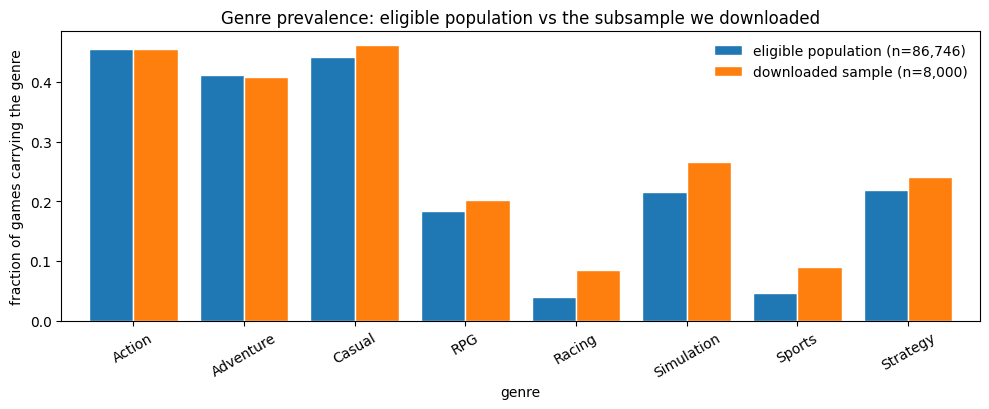

,"eligible population (n=86,746) %","downloaded sample (n=8,000) %"
Action,45.4000,45.5000
Adventure,41.1000,40.8000
Casual,44.1000,46.2000
RPG,18.3000,20.2000
Racing,4.0000,8.5000
Simulation,21.5000,26.6000
Sports,4.6000,8.9000
Strategy,21.9000,24.0000


In [4]:
# Population vs sample: the visible consequence of the hybrid sampling decision.
sampling = report["sampling"]
population = pd.Series(sampling["pool_genre_fractions"]).reindex(GENRES)
sample = pd.Series(sampling["selected_genre_fractions"]).reindex(GENRES)

frame = pd.DataFrame(
    {
        "eligible population (n=%s)" % f"{sampling['eligible_pool']:,}": population,
        "downloaded sample (n=%s)" % f"{sampling['selected']:,}": sample,
    }
)
axis = frame.plot.bar(figsize=(10, 4.2), width=0.8, edgecolor="white")
axis.set_ylabel("fraction of games carrying the genre")
axis.set_xlabel("genre")
axis.set_title("Genre prevalence: eligible population vs the subsample we downloaded")
axis.legend(frameon=False)
axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

frame.mul(100).round(1).rename(columns=lambda c: c + " %")

## 8. Data cleaning

`gamesense.data.preprocessing.clean_games()` implements the whole pipeline as pure,
unit-tested functions (`tests/test_preprocessing.py`). Every row it removes is counted with a
reason, so the cleaning is auditable rather than asserted.

| Problem | What the pipeline does |
|---|---|
| duplicate `appID` | keep the first occurrence |
| duplicate description | keep the first occurrence (re-skinned asset-flip clones share copy) |
| missing / empty description | drop |
| description shorter than 15 words | drop — too little signal to be a fair test of the text model |
| description longer than 400 words | drop — pathological store pages |
| predominantly non-Latin description | drop — `distilbert-base-uncased` is an English model |
| no genre in the target label space | drop |
| fewer screenshots than required | drop |
| sexually explicit / adult-only content | drop (four-signal screen, see below) |
| unmapped / non-gameplay genre strings | ignored as labels (counted, not silently lost) |
| unreadable or corrupt downloaded image | drop the sample |
| near-duplicate screenshots | drop by 64-bit average hash |

### Text cleaning for a Transformer, not for a bag of words

A frequent mistake when preparing text for BERT-style models is to apply the classical NLP
recipe: lower-case, strip punctuation, remove stop words, stem. That destroys exactly the
information a pretrained WordPiece model was trained on. `clean_description()` therefore
removes only genuine noise — HTML tags and entities, Steam BBCode, URLs, e-mail addresses,
bullet glyphs, zero-width characters, "About This Game" boiler-plate and runs of repeated
punctuation — and **preserves** sentence punctuation, capitalisation, numbers and word order.
(`distilbert-base-uncased` performs its own lower-casing inside the tokenizer.)

### Screening adult content

This project renders real screenshots into a report and into a public application, so sexually
explicit games have to be excluded outright. Steam's structured metadata is not a sufficient
guide: fewer than 200 of the 124k rows carry a `Nudity` or `Sexual Content` **genre**, while
roughly one row in ten is in fact adult material. `adult_content_mask()` therefore combines
four independent signals:

1. the `Nudity` / `Sexual Content` genre tags;
2. `required_age >= 18`;
3. Steam's free-text `notes` content advisory;
4. an explicit keyword screen over the title and the short description.

The screen is deliberately conservative -- it prefers dropping a borderline game to keeping an
explicit one -- and the number of rows it removes is reported below rather than buried, because
it does change the population being studied (it removes a non-random slice, weighted towards
`Casual` and `Adventure` visual novels). That consequence is listed again in Section 25.

In [5]:
from gamesense.data.preprocessing import clean_description, mask_genre_terms, remove_title_mentions

messy = (
    "<h2>About This Game</h2><p>Explore  a  vast  fantasy world!!!  "
    "Visit <a href='https://example.com/store'>our store</a> or mail us at dev@studio.com. "
    "[b]Features:[/b] &amp; much more…</p>"
)
print("RAW    :", messy)
print("CLEANED:", clean_description(messy))

RAW    : <h2>About This Game</h2><p>Explore  a  vast  fantasy world!!!  Visit <a href='https://example.com/store'>our store</a> or mail us at dev@studio.com. [b]Features:[/b] &amp; much more…</p>
CLEANED: Explore a vast fantasy world! Visit our store or mail us at Features: & much more.


In [6]:
# What the cleaning pass removed, and why.
cleaning = report["cleaning"]
dropped = pd.Series(cleaning["dropped_by_reason"], name="rows dropped").sort_values(ascending=False)
dropped_frame = dropped.to_frame()
dropped_frame["% of raw"] = (100 * dropped / cleaning["rows_in"]).round(2)

print(f"raw rows           : {cleaning['rows_in']:,}")
print(f"surviving rows     : {cleaning['rows_out']:,}")
print(f"dropped in total   : {cleaning['rows_dropped_total']:,}"
      f" ({100 * cleaning['rows_dropped_total'] / cleaning['rows_in']:.1f}%)")
assert dropped.sum() == cleaning["rows_dropped_total"], "drop accounting must balance"
print("drop accounting balances: every removed row has exactly one recorded reason.")
dropped_frame

raw rows           : 124,146
surviving rows     : 86,746
dropped in total   : 37,400 (30.1%)
drop accounting balances: every removed row has exactly one recorded reason.


,rows dropped,% of raw
description_too_short,12895,10.3900
adult_content,10258,8.2600
missing_description,8317,6.7000
no_target_genre,4953,3.9900
duplicate_description,713,0.5700
non_english_description,227,0.1800
no_screenshot,25,0.0200
fewer_than_2_screenshots,11,0.0100
missing_title,1,0.0000


### 8.1 Choosing the label space

Steam's `genres` field is not a clean taxonomy. It mixes gameplay genres with studio-size and
monetisation descriptors, multiplayer *modes*, non-game software categories and content
warnings. Using it verbatim would produce a label space in which the most frequent "genre" is
*Indie* — a statement about the publisher, not about the game.

The label space was therefore chosen from measured frequencies plus an explicit editorial
rule: **keep gameplay genres with sufficient support; exclude everything that describes the
business, the release state, the multiplayer mode, or the software category.** The resulting
8 classes are `Action, Adventure, Casual, RPG, Racing, Simulation, Sports, Strategy`.

Two deviations from the original project brief are worth stating: Steam has no *Shooter*
genre (shooters are tagged *Action*), so *Casual* — a genuine, well-supported Steam gameplay
genre — takes its place; and *Massively Multiplayer* is excluded because it is a multiplayer
mode rather than a genre, and has too little support to estimate a per-class F1 from.

In [7]:
from collections import Counter

raw_genre_counts = Counter(
    genre for genres in raw["genres"].dropna() for genre in (list(genres) if genres is not None else [])
)
table = pd.DataFrame(
    sorted(raw_genre_counts.items(), key=lambda kv: -kv[1]), columns=["steam genre", "games"]
)
table["% of raw"] = (100 * table["games"] / len(raw)).round(2)
table["used as a label?"] = np.where(
    table["steam genre"].isin(GENRES),
    "YES",
    table["steam genre"].map(lambda g: "no — " + EXCLUDED_GENRE_REASONS.get(g, "not a gameplay genre")),
)
table.head(22)

,steam genre,games,% of raw,used as a label?
0,Indie,81746,65.8500,"no — studio-size / business descriptor, not ga..."
1,Casual,50886,40.9900,YES
2,Action,46743,37.6500,YES
3,Adventure,45726,36.8300,YES
4,Simulation,24504,19.7400,YES
5,Strategy,22725,18.3100,YES
6,RPG,21259,17.1200,YES
7,Free To Play,12366,9.9600,"no — monetisation model, not gameplay"
8,Early Access,11324,9.1200,"no — release state, not gameplay"
9,Sports,4925,3.9700,YES


In [8]:
label_space = load_json(CONFIG.paths.label_space)
support = pd.DataFrame(
    {
        "games with this genre": pd.Series(label_space["support_games"]).reindex(GENRES),
        "prevalence in sample": pd.Series(label_space["prevalence_games"]).reindex(GENRES),
    }
)
print(f"minimum support required : {label_space['min_genre_support']}")
print(f"genres below that floor  : {label_space['under_supported'] or 'none'}")
support

minimum support required : 150
genres below that floor  : none


,games with this genre,prevalence in sample
Action,3629,0.4552
Adventure,3260,0.4089
Casual,3672,0.4606
RPG,1618,0.2030
Racing,677,0.0849
Simulation,2124,0.2664
Sports,708,0.0888
Strategy,1909,0.2395


## 9. Data-leakage analysis

Two distinct leakage risks exist in this project, and they need different countermeasures.

### 9.1 Textual leakage: the description gives the answer away

Store descriptions are marketing copy, and marketing copy names the product and its genre:

> *"The Elder Scrolls V: Skyrim is an open-world **role-playing game**…"*

A model trained on that sentence can reach a high F1 without understanding anything: it only
has to learn that the token *Skyrim* co-occurs with `RPG`, and that the literal phrase
*role-playing game* implies `RPG`. Both are memorisation of a surface form, and neither
transfers to an unreleased game whose title the model has never seen.

`preprocessing.py` therefore produces **three** description variants for every game, and the
headline experiments use the *second* one:

| column | what it contains | used for |
|---|---|---|
| `description_clean` | cleaned text, title left in | the RQ6 "leaky" control |
| `description_notitle` | title, subtitle, punctuation variants and initialisms replaced by *"this game"* | **all headline results** |
| `description_masked` | additionally, explicit genre vocabulary replaced by `[GENRE]` | the stronger keyword ablation |

Title removal is deliberately conservative: variants that are generic words (*"The Game"*,
*"Adventure"*) are never removed, because deleting them would mangle unrelated sentences.
`tests/test_preprocessing.py` pins that behaviour.

### 9.2 Structural leakage: two screenshots of the same game

Each game contributes two screenshots **and one shared description**. If the split were made
over individual images, the *identical* description and a near-identical frame from the same
title would appear in both training and test data, and the reported score would be partly a
memorisation score. All splitting is therefore performed over `app_id` groups and verified
afterwards (Section 11).

In [9]:
example_title = "The Elder Scrolls V: Skyrim"
example_text = (
    "The Elder Scrolls V: Skyrim is an open-world role-playing game. "
    "In Skyrim you explore a huge province, and The Elder Scrolls V rewards curiosity. "
    "It is a turn-free action RPG with a racing minigame."
)
print("ORIGINAL :", example_text)
print()
print("NO TITLE :", remove_title_mentions(example_text, example_title))
print()
print("MASKED   :", mask_genre_terms(remove_title_mentions(example_text, example_title)))

ORIGINAL : The Elder Scrolls V: Skyrim is an open-world role-playing game. In Skyrim you explore a huge province, and The Elder Scrolls V rewards curiosity. It is a turn-free action RPG with a racing minigame.

NO TITLE : this game is an open-world role-playing game. In this game you explore a huge province, and this game rewards curiosity. It is a turn-free action RPG with a racing minigame.

MASKED   : this game is an open-world [GENRE] game. In this game you explore a huge province, and this game rewards curiosity. It is a turn-free [GENRE] with a [GENRE] minigame.


In [10]:
# How much text is actually affected in the real dataset?
from gamesense.data.loader import load_games, load_samples

games = load_games()
samples = load_samples()

changed = (games["description_clean"] != games["description_notitle"])
masked_changed = (games["description_notitle"] != games["description_masked"])
print(f"games                                     : {len(games):,}")
print(f"descriptions containing their own title   : {changed.sum():,} ({100 * changed.mean():.1f}%)")
print(f"descriptions containing genre vocabulary  : {masked_changed.sum():,} "
      f"({100 * masked_changed.mean():.1f}%)")
print()
print("Example of a description that mentions its own title:")
example = games[changed].iloc[0]
print(f"  title : {example['name']}")
print(f"  before: {example['description_clean'][:220]}")
print(f"  after : {example['description_notitle'][:220]}")

games                                     : 7,972
descriptions containing their own title   : 3,962 (49.7%)
descriptions containing genre vocabulary  : 3,741 (46.9%)

Example of a description that mentions its own title:
  title : Funguys Swarm
  before: Funguys Swarm is a cartoony survivor bullet hell where the forest is on fire. Become a Funguy, arm yourself with forest-crafted weapons, and unleash some bonkers powers on the Fireking's army. And maybe. just maybe, save
  after : this game is a cartoony survivor bullet hell where the forest is on fire. Become a Funguy, arm yourself with forest-crafted weapons, and unleash some bonkers powers on the Fireking's army. And maybe. just maybe, save the


## 10. Exploratory data analysis

The figures below describe the **downloaded sample** that the models are trained and evaluated
on, not the Steam catalogue (see Section 7 on sampling).

games                    : 7,972
image samples            : 15,683 (1.97 screenshots per game)
label cardinality (mean) : 2.21 genres per game
label density            : 0.2759 (fraction of all game x genre cells that are positive)


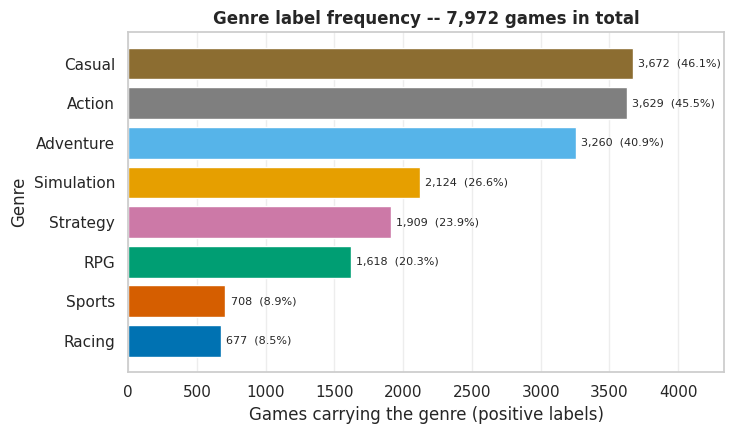

In [11]:
from gamesense.data.preprocessing import label_matrix, positive_counts
from gamesense.visualization import plots

plots.apply_style()
FIGURES = CONFIG.paths.figures

label_array = label_matrix(games)
counts = positive_counts(games)

print(f"games                    : {len(games):,}")
print(f"image samples            : {len(samples):,} "
      f"({len(samples) / len(games):.2f} screenshots per game)")
print(f"label cardinality (mean) : {label_array.sum(axis=1).mean():.2f} genres per game")
print(f"label density            : {label_array.mean():.4f} "
      f"(fraction of all game x genre cells that are positive)")
plots.plot_genre_frequency(counts, total=len(games), save_path=FIGURES / "eda_genre_frequency.png")
plt.show()

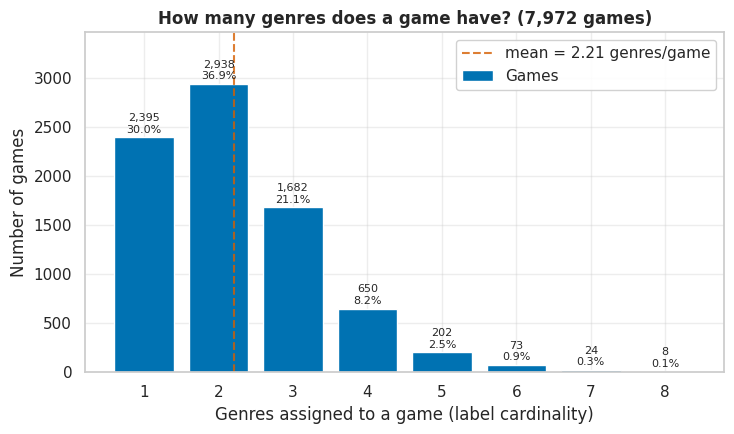

,games,% of sample
genres per game,,
1,2395,30.0000
2,2938,36.9000
3,1682,21.1000
4,650,8.2000
5,202,2.5000
6,73,0.9000
7,24,0.3000
8,8,0.1000


In [12]:
plots.plot_labels_per_game(
    label_array.sum(axis=1).astype(int), save_path=FIGURES / "eda_labels_per_game.png"
)
plt.show()

cardinality = pd.Series(label_array.sum(axis=1).astype(int)).value_counts().sort_index()
pd.DataFrame(
    {"games": cardinality, "% of sample": (100 * cardinality / len(games)).round(1)}
).rename_axis("genres per game")

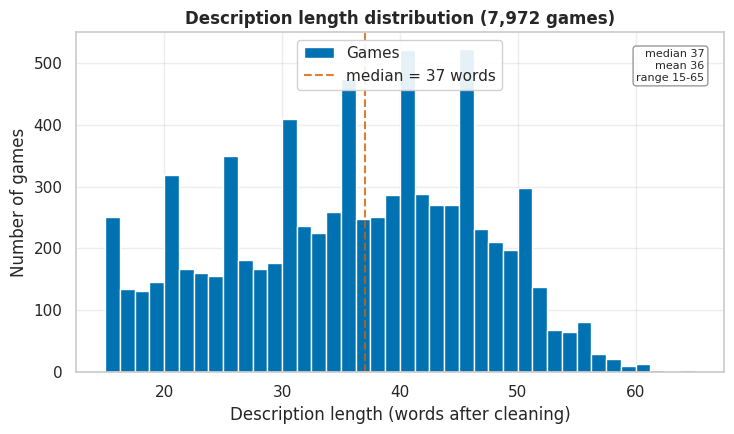

,description length (words)
count,7972.0000
mean,35.8019
std,10.6057
min,15.0000
25%,27.7500
50%,37.0000
75%,44.0000
max,65.0000


In [13]:
plots.plot_description_length(
    games["description_word_count"], save_path=FIGURES / "eda_description_length.png"
)
plt.show()
games["description_word_count"].describe().to_frame("description length (words)")

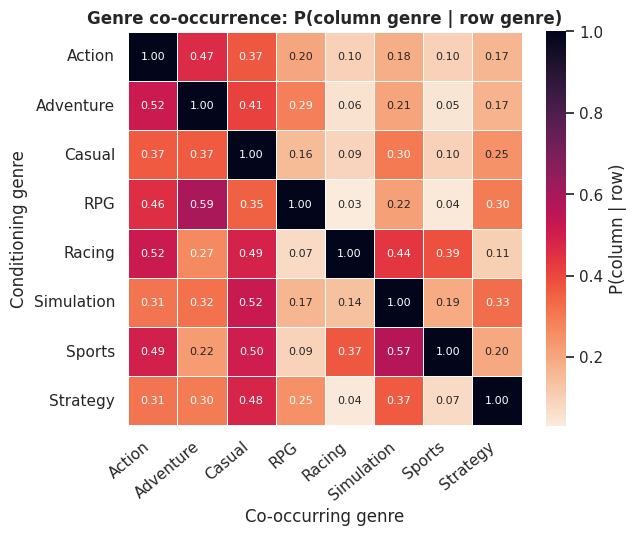

In [14]:
plots.plot_genre_cooccurrence(
    label_array, classes=GENRES, save_path=FIGURES / "eda_genre_cooccurrence.png"
)
plt.show()

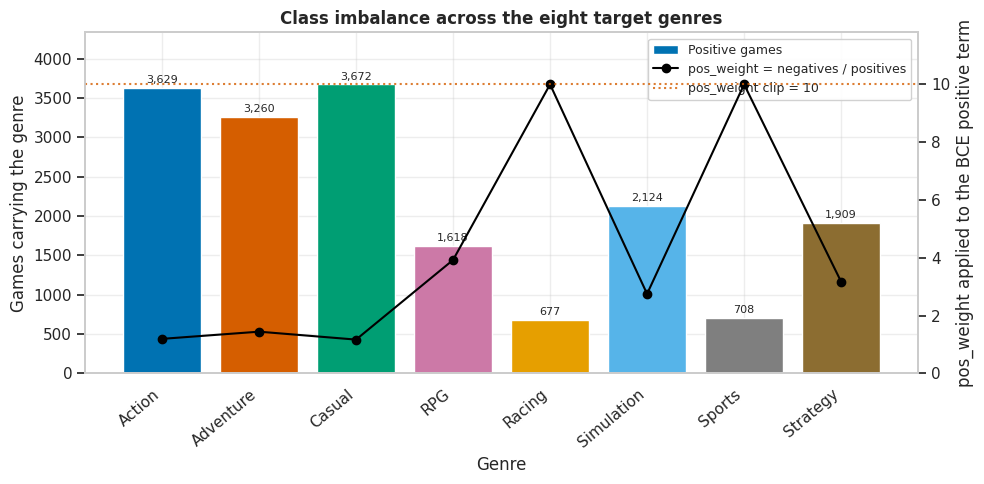

In [15]:
from gamesense.data.preprocessing import class_weights

plots.plot_class_imbalance(
    counts,
    pos_weights=dict(zip(GENRES, class_weights(label_array, clip=CONFIG.training.pos_weight_clip))),
    save_path=FIGURES / "eda_class_imbalance.png",
)
plt.show()

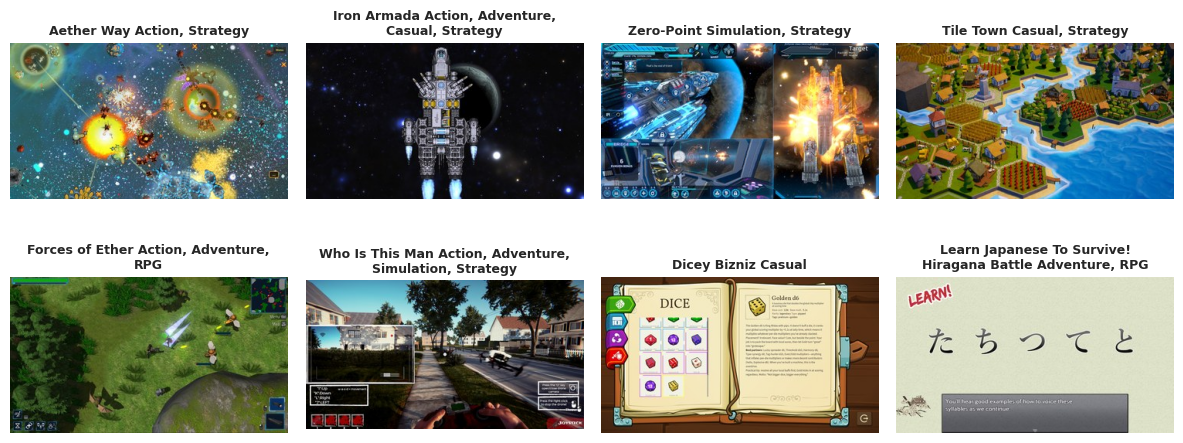

In [16]:
# A look at the actual inputs: real screenshots with their real labels.
shown = samples.merge(games[["app_id", "name", "genres"]], on="app_id", how="left")
shown = shown.drop_duplicates("app_id").sample(8, random_state=CONFIG.training.seed)
plots.plot_sample_images(
    shown["image_path"].tolist(),
    [f"{row['name']}\n{row['genres'].replace('|', ', ')}" for _, row in shown.iterrows()],
    root=CONFIG.paths.root,
    ncols=4,
    save_path=FIGURES / "eda_sample_screenshots.png",
)
plt.show()

In [17]:
# And the paired text for the same games.
for _, row in shown.head(3).iterrows():
    print(f"--- {row['name']}  [{row['genres'].replace('|', ', ')}]")
    print(f"    {games.loc[games['app_id'] == row['app_id'], 'description_notitle'].iloc[0]}")
    print()

--- Aether Way  [Action, Strategy]
    this game is a 2D space RTS with action/roguelike elements. You play as some abstract life form that travels across the space and evolves.

--- Iron Armada  [Action, Adventure, Casual, Strategy]
    this game is a multiplayer, space-faring combat game where players must team up to build a fleet of ships in order to survive the perils of space and defeat the opposing player faction. Build ships of all shapes and sizes, mine resources, and scavenge parts with friends to conquer the universe!

--- Zero-Point  [Simulation, Strategy]
    this game is a 3D space roguelike featuring tactical ship-to-ship combat, crew command and an immersive view of your ship's interior. As Captain of a Star Federation cruiser, lead your crew and ship to victory over the rebellious Galactic Liberation Front!



## 11. Deep learning fundamentals used in this project

This section states the machinery GameSense relies on, and — for each concept — where it
actually appears in the code. It is deliberately compact: the aim is to show that the design
choices in Sections 14–18 are *choices*, made for reasons.

### 11.1 A neural network as a parameterised function

A feed-forward layer is an affine map followed by a non-linearity:

$$
\mathbf{h}^{(l)} = \phi\!\left( W^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)} \right),
\qquad \phi(z) = \max(0, z) \ \ (\text{ReLU}).
$$

Stacking such layers and composing them with convolutions or attention blocks gives a
function $f_\theta$ flexible enough to approximate the mapping we want. Without $\phi$ the
whole stack would collapse to a single affine map, which could not represent "a cockpit *and*
a lap counter implies Racing".

**In GameSense:** `MLPHead` in `models/model_utils.py` is `Dropout → [Linear → LayerNorm →
ReLU → Dropout]* → Linear`.

### 11.2 Forward propagation

Forward propagation is just evaluating $f_\theta$: pixels flow through ResNet18's convolution
stages to a 512-d vector; tokens flow through DistilBERT's six transformer blocks to a 768-d
vector; the fusion MLP maps the concatenation to $C = 8$ **logits** $\mathbf{z}$.

### 11.3 From logits to probabilities: sigmoid, not softmax

$$
\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \hat p_c = \sigma(z_c).
$$

Each genre gets its **own independent** Bernoulli probability. The softmax alternative

$$
\text{softmax}(\mathbf{z})_c = \frac{e^{z_c}}{\sum_{k} e^{z_k}}
$$

forces $\sum_c \hat p_c = 1$, so the classes **compete**: raising $P(\text{RPG})$ must lower
$P(\text{Action})$. For a game that is genuinely both, that is the wrong model of the world
(Section 12 develops this).

### 11.4 Loss function

Binary cross entropy for one label:

$$
\ell(y, p) = -\big[\, y \log p + (1-y)\log(1-p) \,\big],
$$

and for the whole multi-label output,

$$
L = \frac{1}{C}\sum_{c=1}^{C} \ell(y_c, \sigma(z_c)).
$$

BCE is the negative log-likelihood of independent Bernoulli labels, so minimising it is
maximum-likelihood estimation. Note that $\ell \to \infty$ as a confident prediction becomes
wrong — the loss punishes confident mistakes far more than hesitant ones.

**In GameSense:** `torch.nn.BCEWithLogitsLoss`, which consumes logits and fuses the sigmoid
into the loss for numerical stability (`training/losses.py`).

### 11.5 Gradient descent and backpropagation

Parameters move against the gradient,

$$
\theta \leftarrow \theta - \eta \, \nabla_\theta L ,
$$

and the gradient is obtained by **backpropagation**: the chain rule applied in reverse
topological order over the computation graph, reusing intermediate results so that one
backward pass costs about the same as one forward pass. For a two-layer example with
$L = \ell(f(\mathbf{h}))$ and $\mathbf{h} = \phi(W\mathbf{x} + \mathbf{b})$,

$$
\frac{\partial L}{\partial W}
= \underbrace{\frac{\partial L}{\partial \mathbf{h}}}_{\text{from the layer above}}
\odot\ \phi'(W\mathbf{x} + \mathbf{b})\ \mathbf{x}^{\!\top}.
$$

**In GameSense:** `loss.backward()` in `training/trainer.py`, followed by gradient-norm
clipping at 1.0 to stop a rare large batch gradient from destabilising the run.

### 11.6 Optimiser: AdamW

Plain SGD uses one learning rate for every parameter. Adam keeps exponential moving averages
of the gradient ($m_t$) and its square ($v_t$) and rescales each step:

$$
\theta_{t+1} = \theta_t - \eta \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}.
$$

**AdamW** additionally *decouples* weight decay from the adaptive term, applying it directly
to the parameters rather than folding it into the gradient — which is what makes it behave as
a genuine L2 regulariser for transformer-style models.

**In GameSense:** `torch.optim.AdamW` with two parameter groups — a large learning rate
($10^{-3}$) for the randomly initialised heads and a small one ($2\times10^{-5}$) for any
unfrozen pretrained layer — plus linear warmup and cosine decay. Bias and normalisation
parameters are excluded from weight decay, as is conventional.

### 11.7 Overfitting, regularisation, dropout

A model with millions of parameters and thousands of examples can memorise. The symptom is a
widening gap between training and validation loss. GameSense uses five countermeasures, all
visible in the training curves of Section 19:

1. **frozen pretrained encoders** — the vast majority of parameters cannot overfit because
   they cannot move at all;
2. **dropout** ($p = 0.3$) — during training each unit is zeroed with probability $p$ and
   activations are rescaled by $1/(1-p)$, which prevents the head from relying on any single
   feature and acts like an implicit ensemble;
3. **weight decay** ($10^{-2}$, AdamW);
4. **light image augmentation** (random resized crop, horizontal flip, mild colour jitter);
5. **early stopping** on validation micro-F1, restoring the best epoch's weights.

### 11.8 Embeddings

An embedding is a learned vector representation in which geometry means something. GameSense
uses three kinds: WordPiece **token** embeddings inside DistilBERT; the pooled **sentence**
embedding (768-d) that summarises a description; and the pooled **image** embedding (512-d)
that summarises a screenshot. Fusion is possible precisely because both modalities end up as
vectors in a space where a linear layer can compare them.

### 11.9 Transfer learning

Pretraining learns general structure from a large corpus (1.28M ImageNet photographs; a large
English text corpus); transfer reuses it for a small task. Two regimes:

* **feature extraction** — freeze the encoder, train a new head. Few trainable parameters,
  little overfitting risk, very cheap. *This is the GameSense default.*
* **fine-tuning** — additionally unfreeze the last block(s) with a small learning rate. More
  capacity to adapt, more risk, much more compute. *Available via `--unfreeze-stages` /
  `--unfreeze-layers` and reported as an auxiliary experiment.*

Freezing has a second, underrated benefit here: a frozen encoder in `eval` mode is a
*deterministic* function of its input, which is what allows the embeddings to be cached once
and reused for every epoch and every seed (Section 17).

### 11.10 Train / validation / test

* **train** — parameters are fitted here;
* **validation** — every *decision about* the model is made here: when to stop, which epoch to
  keep, which decision threshold to use;
* **test** — touched exactly once per model, to report a number.

Any decision informed by test data turns the test score into a training score.

### 11.11 Sequence modelling and attention

A recurrent network processes tokens in order, carrying a hidden state
$\mathbf{h}_t = f(\mathbf{h}_{t-1}, \mathbf{x}_t)$; an LSTM adds gates so gradients can
survive long sequences. Information between positions $i$ and $j$ must still travel
$|i-j|$ steps.

Self-attention connects any two positions in **one** step:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right) V .
$$

Each token emits a query, a key and a value; the softmax over scaled dot products decides how
much every other token contributes. The $\sqrt{d_k}$ divisor keeps the dot products in a range
where the softmax has usable gradients. Multiple heads run in parallel so different heads can
attend to different kinds of relation.

Concretely, in *"explore a vast open world and complete quests"*, attention lets *complete*
look directly at *quests* — the pairing that signals `RPG` — without that signal having to be
carried step by step through a recurrent state.

**In GameSense:** DistilBERT is six such transformer blocks. The optional
`BiLSTMTextClassifier` provides the recurrent contrast point, consuming the *same* WordPiece
ids so the comparison isolates the sequence encoder.

### 11.12 Multi-label classification

Because a game may hold several genres at once, the output is $C$ independent binary
decisions. This changes the loss (BCE, not categorical CE), the activation (sigmoid, not
softmax), the metrics (micro/macro F1, mAP, Hamming loss — not accuracy) and the decision
rule (a threshold per output, tuned on validation). Sections 12, 13, 16 and 19 take each of
those in turn.

## 12. Multi-label classification: why sigmoid and BCE

A game such as *The Witcher 3* is legitimately `Action`, `Adventure` **and** `RPG`. Its
target is therefore a vector, not a class index:

```
Action = 1   Adventure = 1   Casual = 0   RPG = 1
Racing = 0   Simulation = 0  Sports = 0   Strategy = 0
```

### Why softmax is the wrong tool

Softmax models a distribution *over* classes: it normalises the outputs so they sum to one.
That embeds an assumption — exactly one class is correct — which is false here, with two
concrete consequences:

1. **Classes are forced to compete.** With three true genres, the best a softmax can do is
   spread ~0.33 over each. Every genre then looks unlikely, and no fixed threshold can
   recover the label set.
2. **The gradient actively fights the truth.** The categorical cross-entropy gradient
   $\hat{\mathbf{p}} - \mathbf{y}$ pushes *down* on every class other than the single target,
   so training on multi-label data with a softmax teaches the model to suppress genres that
   are genuinely present.

### Why sigmoid + BCE is right

$C$ independent sigmoids let $\hat p_{\text{RPG}} = 0.96$ and $\hat p_{\text{Action}} = 0.91$
coexist. The loss decomposes into $C$ independent binary problems that share a
representation — which is precisely the inductive bias we want: *the features are shared, the
decisions are separate.*

The demonstration below makes the failure concrete on real numbers rather than by assertion.

In [18]:
import torch

# Same logits, two different output layers, one genuinely multi-label target.
logits = torch.tensor([[2.8, 2.2, -2.0, 3.1, -3.5, -1.4, -3.9, -1.1]])
target = torch.zeros(1, NUM_CLASSES)
for genre in ("Action", "Adventure", "RPG"):
    target[0, GENRES.index(genre)] = 1.0

comparison = pd.DataFrame(
    {
        "true label": target[0].numpy().astype(int),
        "sigmoid (used)": torch.sigmoid(logits)[0].numpy(),
        "softmax (wrong)": torch.softmax(logits, dim=1)[0].numpy(),
    },
    index=list(GENRES),
)
print(f"sigmoid probabilities sum to {comparison['sigmoid (used)'].sum():.2f} "
      "(no constraint - each genre is judged on its own)")
print(f"softmax probabilities sum to {comparison['softmax (wrong)'].sum():.2f} "
      "(forced to 1 - the genres must share it out)")
print()
above = comparison[comparison["softmax (wrong)"] >= 0.5]
print(f"genres a 0.5 threshold would recover from softmax: "
      f"{list(above.index) if len(above) else 'none - all three true genres are lost'}")
comparison

sigmoid probabilities sum to 3.42 (no constraint - each genre is judged on its own)
softmax probabilities sum to 1.00 (forced to 1 - the genres must share it out)

genres a 0.5 threshold would recover from softmax: none - all three true genres are lost


,true label,sigmoid (used),softmax (wrong)
Action,1,0.9427,0.3395
Adventure,1,0.9002,0.1863
Casual,0,0.1192,0.0028
RPG,1,0.9569,0.4583
Racing,0,0.0293,0.0006
Simulation,0,0.1978,0.0051
Sports,0,0.0198,0.0004
Strategy,0,0.2497,0.0069


In [19]:
from torch import nn

bce = nn.BCEWithLogitsLoss()
categorical = nn.CrossEntropyLoss()

# CrossEntropyLoss can only be given ONE target class, so it must discard two true genres.
single_target = torch.tensor([GENRES.index("RPG")])
print(f"BCEWithLogitsLoss (all 3 genres kept) : {bce(logits, target).item():.4f}")
print(f"CrossEntropyLoss  (2 genres discarded): {categorical(logits, single_target).item():.4f}")
print()
print("The BCE number is a loss on the real target; the CE number is a loss on a target that")
print("had to be corrupted to fit the loss function. They are not comparable - which is the point.")

BCEWithLogitsLoss (all 3 genres kept) : 0.1116
CrossEntropyLoss  (2 genres discarded): 0.7802

The BCE number is a loss on the real target; the CE number is a loss on a target that
had to be corrupted to fit the loss function. They are not comparable - which is the point.


## 13. Methodology

### 13.1 The controlled comparison

The research question is about the *modality*, so everything else is held fixed. All three
systems share:

| Held constant | Value |
|---|---|
| games, labels, split | identical `data/splits/*.csv`, game-level, seed 42 |
| label space | the same 8 genres |
| loss | `BCEWithLogitsLoss` with the same `pos_weight` vector |
| optimiser | AdamW, same learning rates, same weight decay, same warmup + cosine schedule |
| head recipe | `Dropout → Linear → LayerNorm → ReLU → Dropout → Linear`, dropout 0.3 |
| early stopping | validation micro-F1, patience 8, best epoch restored |
| threshold selection | grid search on **validation** only |
| metrics | one implementation, `evaluation/metrics.py` |
| training loop | one implementation, `training/trainer.py` |

The only differences are which encoder(s) run and what the head receives. A single `Trainer`
drives all three, which is why the comparison cannot be confounded by three slightly
different training loops.

### 13.2 Architectures

```
MODEL A — image only                MODEL B — text only
────────────────────                ───────────────────
screenshot                          description
   │                                   │
   ▼                                   ▼
resize 224² + ImageNet norm          WordPiece tokenizer (max 128)
   │                                   │
   ▼                                   ▼
ResNet18  (frozen, ImageNet)         DistilBERT (frozen, 6 layers)
   │                                   │
   ▼                                   ▼
global avg-pool → 512-d              masked mean-pool → 768-d
   │                                   │
   ▼                                   ▼
MLP head (512→256→8)                 MLP head (768→256→8)
   │                                   │
   ▼                                   ▼
8 logits → sigmoid                   8 logits → sigmoid


MODEL C — multimodal
────────────────────
        screenshot            description
             │                     │
             ▼                     ▼
        ResNet18               DistilBERT
             │                     │
        512-d visual           768-d text
             │                     │
        L2 normalise          L2 normalise
             └──────── concat ─────┘
                       │
                   1280-d fused
                       │
              fusion MLP 1280→512→256
                       │
                 8 logits → sigmoid
```

### 13.3 Design decisions, and why

**Why ResNet18 rather than something larger?** It is the standard small-vision baseline: 11.7M
parameters, 1.8 GFLOPs per image, well-understood, and its residual connections make the
depth trainable in the first place. On a CPU-only machine a larger backbone would buy a little
accuracy at several times the cost, and would not change the answer to the research question.
The last convolutional stage is also a good Grad-CAM target: 7×7 spatial resolution is coarse
enough to be stable and fine enough to localise.

**Why DistilBERT rather than BERT-base?** ~40% fewer parameters and ~60% faster inference for
almost all of the language ability, achieved by knowledge distillation from BERT. On this
hardware that is the difference between a feasible and an infeasible experiment grid.

**Why masked mean pooling rather than `[CLS]`?** DistilBERT drops BERT's next-sentence
objective, so its `[CLS]` state is not a *trained* sentence summary. Averaging token states
over the attention mask is the more reliable sentence embedding for a frozen encoder.

**Why frozen encoders by default?** With a few thousand training games, fine-tuning 78M
parameters would overfit quickly and cost hours per epoch on CPU. Freezing keeps the
trainable parameter count in the hundreds of thousands, makes the three systems directly
comparable, and — because a frozen encoder is deterministic — makes the multi-seed grid
affordable via feature caching.

**Why concatenation fusion rather than cross-attention?** Because the question is *whether*
fusion helps. Concatenation is the minimal fusion operator: it adds no assumption about how
the two spaces relate, and it keeps Model C architecturally comparable to Models A and B
(same head recipe, same loss). A cross-attention model would confound "fusion helps" with
"a bigger model helps". Cross-attention is listed under future work, not smuggled in here.

**Why L2-normalise before concatenating?** Average-pooled ResNet features and mean-pooled
DistilBERT states have different natural magnitudes. Without normalisation the first fusion
layer sees one block of inputs that is systematically larger, and the *scale* of a modality
influences the model as much as its *content*. Normalising removes that artefact. The ablation
`--no-normalize-embeddings` tests whether it matters (Section 21.3).

## 14. Model A — the image-only classifier

`gamesense.models.image_model.ImageOnlyClassifier` wraps an ImageNet-pretrained ResNet18,
truncated after global average pooling, with a multi-label MLP head.

**Why the residual architecture matters.** Stacking many plain convolutional layers makes
optimisation *harder*, not just slower: the signal has to survive many multiplications on the
way back. A residual block instead computes $\mathbf{h}_{l+1} = \mathbf{h}_l +
\mathcal{F}(\mathbf{h}_l)$, so the identity path gives the gradient a route that does not
attenuate, and each block only has to learn a *correction*. That is what makes an 18-layer
network reliably trainable and is why ResNet remains the default small vision backbone.

**What is trainable.** With the backbone frozen, all 11.2M convolutional parameters are fixed
and only the head is fitted. The encoder is additionally kept in `eval` mode whenever the model
is put into training mode — otherwise its BatchNorm running statistics would keep drifting even
though no gradient reaches them, and the "frozen" features would silently change from epoch to
epoch. `FrozenAwareModule` enforces this.

In [20]:
import torch

from gamesense.models import build_model

image_model = build_model("image")
info = image_model.describe()
print(json.dumps(info, indent=2))

# A real forward pass, with the shapes at every stage.
dummy = torch.randn(4, 3, CONFIG.image.image_size, CONFIG.image.image_size)
with torch.inference_mode():
    feature_map = image_model.encoder.feature_map(dummy)
    embedding = image_model.encoder(dummy)
    logits = image_model(image=dummy)
    probabilities = torch.sigmoid(logits)

print()
print(f"input                       : {tuple(dummy.shape)}")
print(f"layer4 feature map          : {tuple(feature_map.shape)}   <- Grad-CAM target")
print(f"pooled visual embedding     : {tuple(embedding.shape)}")
print(f"logits                      : {tuple(logits.shape)}  range "
      f"[{logits.min():.2f}, {logits.max():.2f}]  (unbounded - these are logits)")
print(f"probabilities after sigmoid  : range [{probabilities.min():.3f}, {probabilities.max():.3f}]")
print(f"trainable / total parameters: {info['parameters']['trainable']:,}"
      f" / {info['parameters']['total']:,}"
      f"  ({100 * info['trainable_fraction']:.2f}% trainable)")

11:05:25 | INFO    | gamesense.models.image       | ImageEncoder(resnet18, pretrained=True, frozen=True, unfrozen_stages=0)


{
  "class": "ImageOnlyClassifier",
  "modality": "image",
  "num_classes": 8,
  "parameters": {
    "total": 11310408,
    "trainable": 133896,
    "frozen": 11176512
  },
  "trainable_fraction": 0.01184,
  "frozen_pretrained": [
    "encoder."
  ],
  "backbone": "resnet18",
  "backbone_pretrained": true,
  "embedding_dim": 512,
  "image_size": 224
}



input                       : (4, 3, 224, 224)
layer4 feature map          : (4, 512, 7, 7)   <- Grad-CAM target
pooled visual embedding     : (4, 512)
logits                      : (4, 8)  range [-0.73, 0.95]  (unbounded - these are logits)
probabilities after sigmoid  : range [0.324, 0.721]
trainable / total parameters: 133,896 / 11,310,408  (1.18% trainable)


## 15. Model B — the text-only classifier

`gamesense.models.text_model.TextOnlyClassifier` uses a frozen DistilBERT encoder plus masked
mean pooling and the same head recipe as Model A.

**Tokenisation.** Descriptions are segmented with DistilBERT's WordPiece vocabulary, truncated
at 128 tokens and padded to the longest sequence *in the batch* rather than to 128. Steam
descriptions average roughly 50 WordPiece tokens, so dynamic padding is about 2.5× faster on
CPU with no effect on the result.

**Pooling.** $\mathbf{e} = \frac{\sum_t m_t \mathbf{h}_t}{\sum_t m_t}$ over the attention mask
$m$, so padding contributes nothing.

**The BiLSTM contrast.** `BiLSTMTextClassifier` is trained end to end on the *same* WordPiece
ids, so the only difference from Model B is the sequence encoder: recurrence with a
learned-from-scratch embedding table versus pretrained self-attention. Its purpose is to show
what the pretrained Transformer is actually buying (Section 21.3).

In [21]:
from gamesense.data.loader import get_tokenizer

tokenizer = get_tokenizer()
text_model = build_model("text")
print(json.dumps(text_model.describe(), indent=2))

example_descriptions = games["description_notitle"].head(4).tolist()
encoded = tokenizer(
    example_descriptions,
    padding=True,
    truncation=True,
    max_length=CONFIG.text.max_length,
    return_tensors="pt",
)
with torch.inference_mode():
    text_logits = text_model(
        input_ids=encoded["input_ids"], attention_mask=encoded["attention_mask"]
    )
    text_embedding = text_model.encoder(encoded["input_ids"], encoded["attention_mask"])

print()
print(f"batch padded to             : {encoded['input_ids'].shape[1]} tokens"
      f"  (cap is {CONFIG.text.max_length}; dynamic padding saves the difference)")
print(f"pooled text embedding       : {tuple(text_embedding.shape)}")
print(f"logits                      : {tuple(text_logits.shape)}")
print()
print("First description, as the model sees it:")
print(" raw   :", example_descriptions[0][:150])
print(" tokens:", tokenizer.convert_ids_to_tokens(encoded["input_ids"][0][:26]))

11:05:26 | INFO    | gamesense.data.loader        | Loading tokenizer 'distilbert-base-uncased'


11:05:28 | INFO    | gamesense.models.text        | TextEncoder(distilbert-base-uncased, pooling=mean, frozen=True, unfrozen_layers=0)


{
  "class": "TextOnlyClassifier",
  "modality": "text",
  "num_classes": 8,
  "parameters": {
    "total": 66562312,
    "trainable": 199432,
    "frozen": 66362880
  },
  "trainable_fraction": 0.003,
  "frozen_pretrained": [
    "encoder."
  ],
  "text_model": "distilbert-base-uncased",
  "pooling": "mean",
  "embedding_dim": 768,
  "max_length": 128
}



batch padded to             : 68 tokens  (cap is 128; dynamic padding saves the difference)
pooled text embedding       : (4, 768)
logits                      : (4, 8)

First description, as the model sees it:
 raw   : Wizard ShrimpTM is a bullet-hell roguelite game where you play as a Shrimp who is inexplicably also a Wizard?! Battle your way out of a slimy swamp, e
 tokens: ['[CLS]', 'wizard', 'shrimp', '##tm', 'is', 'a', 'bullet', '-', 'hell', 'rogue', '##lite', 'game', 'where', 'you', 'play', 'as', 'a', 'shrimp', 'who', 'is', 'in', '##ex', '##pl', '##ica', '##bly', 'also']


In [22]:
# Token counts across the whole dataset - justification for the 128-token cap.
token_lengths = np.array(
    [
        len(tokenizer(text, truncation=True, max_length=512)["input_ids"])
        for text in games["description_notitle"].head(2000)
    ]
)
print(f"WordPiece tokens per description (first 2,000 games)")
print(f"  median            : {np.median(token_lengths):.0f}")
print(f"  mean              : {token_lengths.mean():.1f}")
print(f"  95th percentile   : {np.percentile(token_lengths, 95):.0f}")
print(f"  max               : {token_lengths.max()}")
print(f"  truncated at {CONFIG.text.max_length}: "
      f"{100 * (token_lengths > CONFIG.text.max_length).mean():.2f}% of descriptions")

WordPiece tokens per description (first 2,000 games)
  median            : 47
  mean              : 46.2
  95th percentile   : 67
  max               : 93
  truncated at 128: 0.00% of descriptions


## 16. Model C — the multimodal classifier

The screenshot and the description of a batch element always belong to the **same game**: the
dataset joins the game-level text onto each `(game, screenshot)` sample by `app_id`, so a
mismatch is structurally impossible, and `MultimodalClassifier.fuse()` additionally refuses
mismatched batch sizes rather than silently broadcasting.

$$
\mathbf{e}_{\text{fused}} = \Big[\ \widehat{\mathbf{e}}_{\text{img}}\ ;\
\widehat{\mathbf{e}}_{\text{txt}}\ \Big] \in \mathbb{R}^{1280},
\qquad \widehat{\mathbf{e}} = \frac{\mathbf{e}}{\lVert \mathbf{e}\rVert_2},
$$

followed by `1280 → 512 → 256 → 8`.

The fusion MLP is where the interaction lives: a single linear layer on the concatenation
could only add the two modalities' evidence, whereas a hidden layer with a non-linearity can
represent conjunctions — *"a vehicle in the image **and** the word 'lap' in the text"* — which
is exactly the kind of complementarity the research question is about.

In [23]:
multimodal_model = build_model("multimodal")
print(json.dumps(multimodal_model.describe(), indent=2))

with torch.inference_mode():
    fused_logits = multimodal_model(
        image=dummy,
        input_ids=encoded["input_ids"],
        attention_mask=encoded["attention_mask"],
    )
    visual = multimodal_model.encode_image(dummy)
    textual = multimodal_model.encode_text(encoded["input_ids"], encoded["attention_mask"])
    fused = multimodal_model.fuse(visual, textual)

print()
print(f"visual embedding : {tuple(visual.shape)}")
print(f"text embedding   : {tuple(textual.shape)}")
print(f"fused embedding  : {tuple(fused.shape)}  = {visual.shape[1]} + {textual.shape[1]}")
print(f"logits           : {tuple(fused_logits.shape)}")

# Why normalisation matters: the two branches live on different scales.
raw_visual_norm = visual.norm(dim=1).mean().item()
raw_text_norm = textual.norm(dim=1).mean().item()
print()
print(f"mean L2 norm, raw visual embedding : {raw_visual_norm:.3f}")
print(f"mean L2 norm, raw text embedding   : {raw_text_norm:.3f}")
print(f"ratio                              : {raw_text_norm / raw_visual_norm:.2f}x")
print("-> without L2 normalisation the larger block would dominate the first fusion layer")
print("   for reasons of scale rather than content.")

11:05:29 | INFO    | gamesense.models.image       | ImageEncoder(resnet18, pretrained=True, frozen=True, unfrozen_stages=0)


11:05:29 | INFO    | gamesense.models.text        | TextEncoder(distilbert-base-uncased, pooling=mean, frozen=True, unfrozen_layers=0)


11:05:29 | INFO    | gamesense.models.multimodal  | MultimodalClassifier(image=512 + text=768 -> fused=1280, hidden=(512, 256))


{
  "class": "MultimodalClassifier",
  "modality": "multimodal",
  "num_classes": 8,
  "parameters": {
    "total": 78330184,
    "trainable": 790792,
    "frozen": 77539392
  },
  "trainable_fraction": 0.0101,
  "frozen_pretrained": [
    "image_encoder.",
    "text_encoder."
  ],
  "backbone": "resnet18",
  "text_model": "distilbert-base-uncased",
  "image_dim": 512,
  "text_dim": 768,
  "fused_dim": 1280,
  "fusion": "concatenation + MLP",
  "normalize_embeddings_before_fusion": true,
  "modality_dropout": 0.0
}



visual embedding : (4, 512)
text embedding   : (4, 768)
fused embedding  : (4, 1280)  = 512 + 768
logits           : (4, 8)

mean L2 norm, raw visual embedding : 15.317
mean L2 norm, raw text embedding   : 7.854
ratio                              : 0.51x
-> without L2 normalisation the larger block would dominate the first fusion layer
   for reasons of scale rather than content.


In [24]:
# The batch-correspondence guard, demonstrated rather than asserted.
try:
    multimodal_model.fuse(visual[:3], textual[:4])
except ValueError as error:
    print("ValueError raised as intended:")
    print(" ", error)

ValueError raised as intended:
  image and text batches must correspond to the same games: got 3 vs 4 rows


## 17. Experimental setup

### 17.1 Splitting

`gamesense.data.splitting` performs the split at **game** level with **iterative
stratification** (Sechidis et al., 2011): the label with the fewest remaining positives is
placed first, when there is still freedom to place it well, so rare genres end up
proportionally represented in all three splits. A plain random split can easily leave *Racing*
with almost no validation positives, which makes macro-F1 jump around for reasons that have
nothing to do with the model.

The no-leakage guarantee is *checked*, not claimed: `verify_no_group_leakage()` runs inside
`make_splits()` and its result is stored in `data/splits/split_summary.json`.

In [25]:
from gamesense.data.loader import load_bundle
from gamesense.data.splitting import verify_no_group_leakage

bundle = load_bundle()
split_summary = load_json(CONFIG.paths.split_summary)

rows = []
for name in ("train", "val", "test"):
    info = split_summary["splits"][name]
    rows.append(
        {
            "split": name,
            "games": info["n_games"],
            "samples": info["n_samples"],
            "share of games": info["game_fraction"],
            "genres per game": info["labels_per_game_mean"],
        }
    )
print(pd.DataFrame(rows).to_string(index=False))
print()
check = verify_no_group_leakage(bundle.splits)
print(f"seed                          : {split_summary['seed']}")
print(f"requested proportions         : {split_summary['proportions']}")
print(f"no app_id shared across splits : {check['ok']}")
print(f"group overlaps                 : {check['group_overlaps'] or 'none'}")
print(f"sample_id overlaps             : {check['sample_id_overlaps'] or 'none'}")

11:05:30 | INFO    | gamesense.data.loader        | Loaded data bundle: {'n_games': 7972, 'classes': ['Action', 'Adventure', 'Casual', 'RPG', 'Racing', 'Simulation', 'Sports', 'Strategy'], 'splits': {'train': {'n_samples': 10934, 'n_games': 5558}, 'val': {'n_samples': 2384, 'n_games': 1214}, 'test': {'n_samples': 2365, 'n_games': 1200}}}


split  games  samples  share of games  genres per game
train   5558    10934          0.6972           2.2160
  val   1214     2384          0.1523           2.1750
 test   1200     2365          0.1505           2.2000

seed                          : 42
requested proportions         : [0.7, 0.15, 0.15]
no app_id shared across splits : True
group overlaps                 : none
sample_id overlaps             : none


In [26]:
# Independent, explicit re-verification of the property the whole study rests on.
train_ids = set(bundle.train["app_id"].astype(str))
val_ids = set(bundle.val["app_id"].astype(str))
test_ids = set(bundle.test["app_id"].astype(str))

assert not (train_ids & val_ids), "train/val share a game"
assert not (train_ids & test_ids), "train/test share a game"
assert not (val_ids & test_ids), "val/test share a game"
assert train_ids | val_ids | test_ids == set(games["app_id"].astype(str)), "games unaccounted for"
print(f"{len(train_ids):,} + {len(val_ids):,} + {len(test_ids):,} = "
      f"{len(train_ids | val_ids | test_ids):,} games, pairwise disjoint.")
print("Both screenshots of a game, and its single shared description, always live in one split.")

5,558 + 1,214 + 1,200 = 7,972 games, pairwise disjoint.
Both screenshots of a game, and its single shared description, always live in one split.


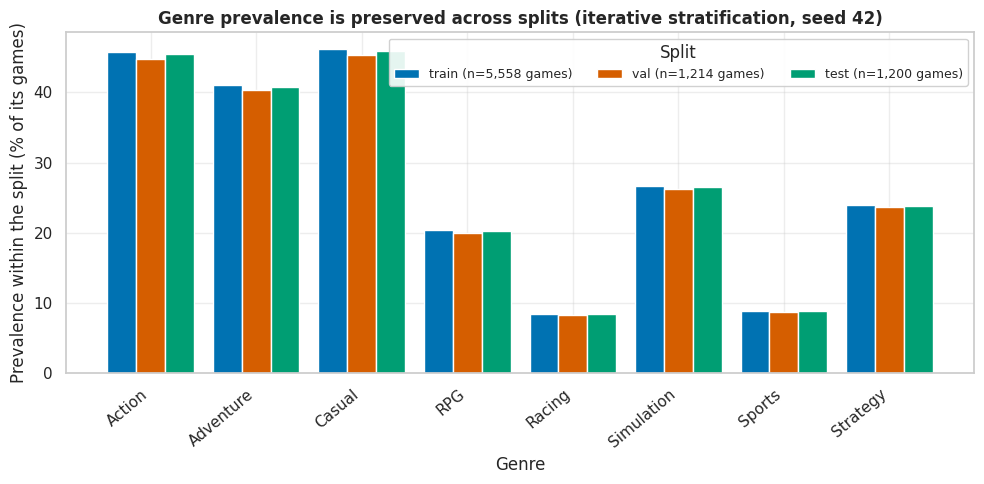

,train,val,test
Action,0.4570,0.4481,0.4542
Adventure,0.4106,0.4028,0.4075
Casual,0.4624,0.4539,0.4592
RPG,0.2037,0.2002,0.2025
Racing,0.0853,0.0832,0.0850
Simulation,0.2675,0.2628,0.2650
Sports,0.0892,0.0873,0.0883
Strategy,0.2404,0.2364,0.2383


In [27]:
plots.plot_split_distribution(split_summary, save_path=FIGURES / "eda_split_distribution.png")
plt.show()

pd.DataFrame(
    {name: split_summary["splits"][name]["genre_prevalence"] for name in ("train", "val", "test")}
).reindex(GENRES)

### 17.2 Class imbalance

The genre prevalences above differ by roughly a factor of five between the most and least
common class (Casual ~46%, Racing ~8.5%). Plain BCE lets a model score respectably by rarely
predicting a rare genre at all, which shows up as a large micro-versus-macro gap.

There are two distinct places to intervene, and they fix different problems:

1. **`pos_weight` in the loss** attacks it as a *learning* problem. The positive term of class
   $c$ is scaled by $w_c = N^{-}_c / N^{+}_c$, computed **from the training split only** and
   clipped at 10 so an almost-empty class cannot dominate the gradient.
2. **Threshold tuning** (Section 19.4) attacks it as a *decision* problem: leave the model
   alone and move the operating point instead.

GameSense treats the choice between them as an experiment rather than an assumption, and the
experiment has an answer. Both configurations were trained for all three systems over three
seeds, and **the decision was made on the validation split**: plain BCE plus threshold tuning
beat `pos_weight` for every system. The configured default is therefore
`class_weighting="none"`, and `pos_weight` is reported as an ablation in Section 21.3.

The intuition for the result is that the two mechanisms are partly redundant. `pos_weight`
raises the predicted probabilities of rare genres, and threshold search then has to raise the
threshold to compensate — the model ends up over-predicting (its predicted label cardinality
drifts above the true one) without ranking any better. Because mAP is threshold-free, it shows
this directly.

Over-sampling was deliberately not tried: with multi-label targets, over-sampling a rare genre
also duplicates whatever frequent genres accompany it, so it distorts the joint label
distribution in a way that is hard to reason about.

In [28]:
from gamesense.training.losses import pos_weight_from_labels

train_labels = bundle.labels_for("train")
weights = pos_weight_from_labels(train_labels, clip=CONFIG.training.pos_weight_clip)

pd.DataFrame(
    {
        "train positives": train_labels.sum(axis=0).astype(int),
        "train negatives": (len(train_labels) - train_labels.sum(axis=0)).astype(int),
        "prevalence": train_labels.mean(axis=0),
        "pos_weight (clipped at %.0f)" % CONFIG.training.pos_weight_clip: weights.numpy(),
    },
    index=list(GENRES),
)

,train positives,train negatives,prevalence,pos_weight (clipped at 10)
Action,5010,5924,0.4582,1.1824
Adventure,4489,6445,0.4106,1.4356
Casual,5039,5895,0.4609,1.1698
RPG,2234,8700,0.2043,3.8931
Racing,939,9995,0.0859,10.0000
Simulation,2922,8012,0.2672,2.7414
Sports,971,9963,0.0888,10.0000
Strategy,2623,8311,0.2399,3.1677


### 17.3 Hyper-parameters

Every value below comes from `src/gamesense/config.py`; nothing is hard-coded in a script or
in this notebook. The learning rates follow the standard discriminative-fine-tuning recipe: a
large rate for the randomly initialised head, a much smaller one for any pretrained layer that
is unfrozen.

In [29]:
setup = {
    "seed (primary)": CONFIG.training.seed,
    "seeds (repeats)": list(CONFIG.training.seeds),
    "epochs (max)": CONFIG.training.epochs,
    "batch size": CONFIG.training.batch_size,
    "optimizer": CONFIG.training.optimizer,
    "head learning rate": CONFIG.training.head_lr,
    "backbone learning rate": CONFIG.training.backbone_lr,
    "weight decay": CONFIG.training.weight_decay,
    "gradient clipping": CONFIG.training.grad_clip_norm,
    "scheduler": f"{CONFIG.training.scheduler} (warmup {CONFIG.training.warmup_ratio:.0%})",
    "dropout": CONFIG.model.dropout,
    "head hidden width": CONFIG.model.head_hidden_dim,
    "fusion hidden widths": list(CONFIG.model.fusion_hidden_dims),
    "class weighting": CONFIG.training.class_weighting,
    "pos_weight clip": CONFIG.training.pos_weight_clip,
    "early stopping": f"{CONFIG.training.monitor_metric} ({CONFIG.training.monitor_mode}),"
                      f" patience {CONFIG.training.early_stopping_patience}",
    "image size": CONFIG.image.image_size,
    "image backbone": f"{CONFIG.image.backbone} (pretrained={CONFIG.image.pretrained})",
    "text model": CONFIG.text.model_name,
    "max tokens": CONFIG.text.max_length,
    "text pooling": CONFIG.text.pooling,
    "default threshold": CONFIG.evaluation.default_threshold,
    "threshold grid": list(CONFIG.evaluation.threshold_grid),
    "threshold strategy": CONFIG.evaluation.threshold_strategy,
}
pd.Series(setup, name="value").to_frame()

,value
seed (primary),42
seeds (repeats),"[42, 123, 2026]"
epochs (max),40
batch size,32
optimizer,adamw
head learning rate,0.0010
backbone learning rate,0.0000
weight decay,0.0100
gradient clipping,1.0000
scheduler,cosine (warmup 5%)


### 17.4 Frozen-encoder feature caching

With both encoders frozen and augmentation disabled, an encoder forward pass is a
*deterministic* function of its input. The embeddings can therefore be computed **once** and
reused for every epoch and every seed. Training the head on cached embeddings is
mathematically the same optimisation problem as running the frozen encoders every epoch — the
head sees exactly the same numbers — but it is roughly two orders of magnitude cheaper on CPU.

That is not a shortcut taken to make the numbers look better; it is what makes the three-seed
grid and the ablations affordable at all on this hardware. The equivalence has two conditions,
both enforced in code:

* the encoders must be frozen (`--unfreeze-stages` / `--unfreeze-layers` disable the cache
  automatically);
* augmentation must be off (`--augment` disables the cache automatically).

The cache key hashes the encoder name, image size, tokenizer length, pooling mode and text
column, and the cached sample ids are checked against the current split on load, so a stale
cache cannot silently be paired with different data.

## 18. Training

Training is performed by the scripts, not by this notebook, so that the notebook stays a
*report* and the experiments stay reproducible from the command line:

```bash
python scripts/train_image.py       --seeds 42 123 2026
python scripts/train_text.py        --seeds 42 123 2026
python scripts/train_multimodal.py  --seeds 42 123 2026
```

One epoch of `training/trainer.py` performs the cycle from Section 11:

1. forward pass → logits;
2. `BCEWithLogitsLoss(logits, targets)`;
3. `loss.backward()` — backpropagation;
4. gradient-norm clipping at 1.0, then `AdamW.step()`, then the LR-schedule step;
5. evaluation on the validation split, which drives the schedule, early stopping and
   checkpoint selection.

The test split is never read during training. Each run writes a training history
(`results/logs/history_*.json`), a checkpoint of the best epoch (`models/*.pt`) and its metrics
(`results/metrics/metrics_*.json`).

**Checkpoint size.** Because a fully frozen pretrained encoder is reproducible from its
published weights, checkpoints store only the tensors training could change. That keeps them
at a few megabytes instead of ~300 MB, and `load_model_from_checkpoint()` rebuilds the encoders
from the published weights before loading the trained head.

In [30]:
# The training histories that produced the reported results.
histories = {}
for kind in MODEL_KINDS:
    path = CONFIG.history_path(kind, CONFIG.training.seed)
    if path.is_file():
        histories[kind] = load_json(path)

summary_rows = []
for kind, history in histories.items():
    meta = history["meta"]
    stopping = meta.get("early_stopping", {})
    summary_rows.append(
        {
            "model": MODEL_DISPLAY_NAMES[kind],
            "epochs run": meta.get("epochs_run"),
            "best epoch": stopping.get("best_epoch"),
            f"best val {meta.get('monitor')}": stopping.get("best_score"),
            "stopped early": stopping.get("stopped_early"),
            "trainable params": meta["model"]["parameters"]["trainable"],
            "train seconds": meta.get("total_seconds"),
            "sec / epoch": round(
                meta.get("total_seconds", 0) / max(1, meta.get("epochs_run", 1)), 2
            ),
        }
    )
pd.DataFrame(summary_rows)

,model,epochs run,best epoch,best val micro_f1,stopped early,trainable params,train seconds,sec / epoch
0,Image Only (ResNet18),25,17,0.4993,True,133896,104.1500,4.1700
1,Text Only (DistilBERT),25,17,0.6394,True,199432,109.5200,4.3800
2,Multimodal (ResNet18 + DistilBERT),16,8,0.6418,True,790792,127.4900,7.9700


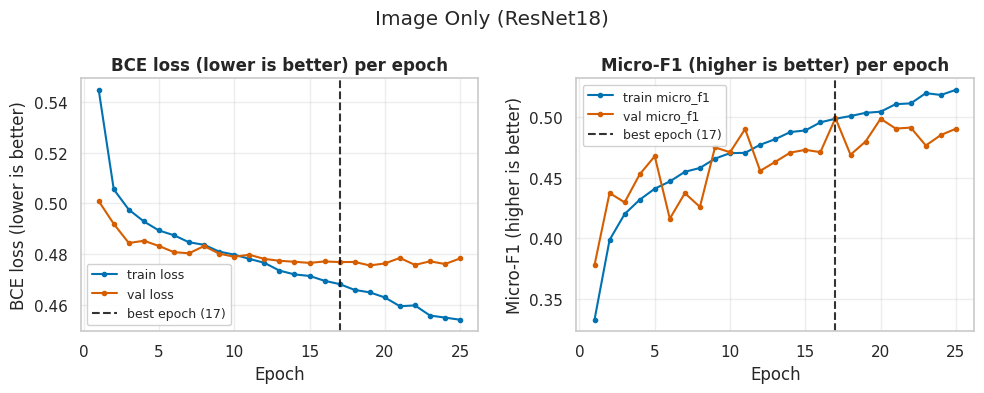

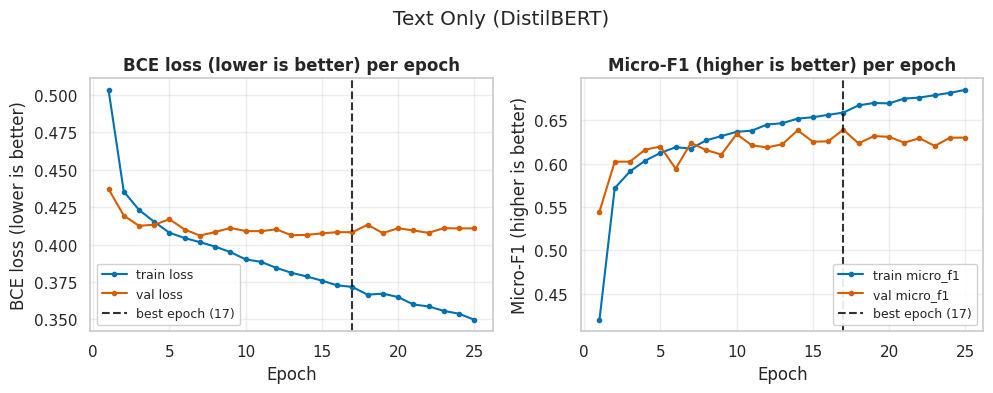

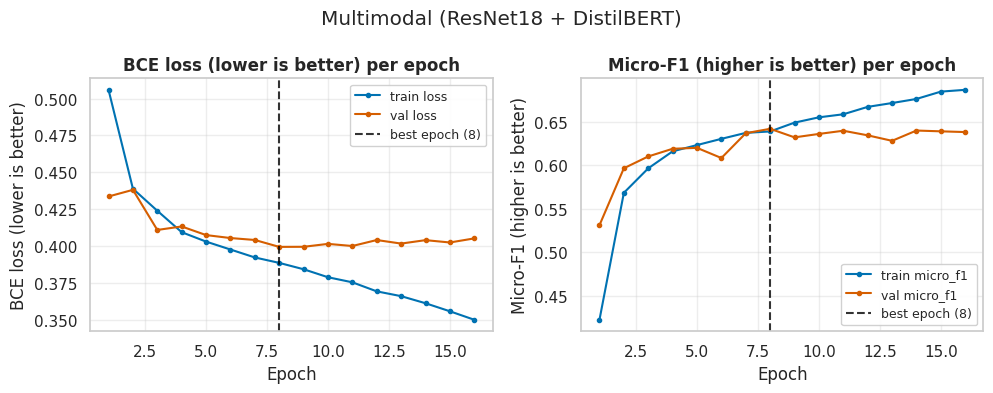

In [31]:
for kind, history in histories.items():
    plots.plot_training_curves(
        history,
        title=MODEL_DISPLAY_NAMES[kind],
        save_path=FIGURES / f"training_curves_{kind}.png",
    )
    plt.show()

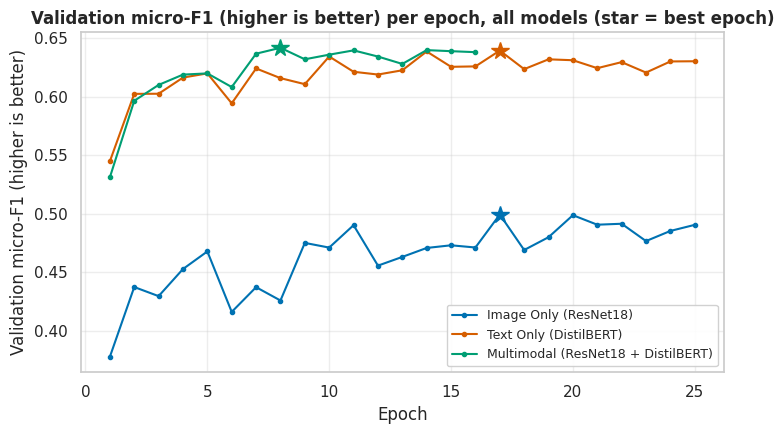

In [32]:
if len(histories) > 1:
    plots.plot_history_comparison(
        histories, metric="val_micro_f1", save_path=FIGURES / "training_comparison.png"
    )
    plt.show()

In [33]:
# Overfitting check: the train-validation gap at the selected epoch.
gap_rows = []
for kind, history in histories.items():
    best = history["meta"]["early_stopping"]["best_epoch"]
    index = history["epochs"].index(best) if best in history["epochs"] else -1
    gap_rows.append(
        {
            "model": MODEL_DISPLAY_NAMES[kind],
            "best epoch": best,
            "train loss": history["train_loss"][index],
            "val loss": history["val_loss"][index],
            "train micro-F1": history["train_micro_f1"][index],
            "val micro-F1": history["val_micro_f1"][index],
            "F1 gap (train - val)": history["train_micro_f1"][index] - history["val_micro_f1"][index],
        }
    )
pd.DataFrame(gap_rows)

,model,best epoch,train loss,val loss,train micro-F1,val micro-F1,F1 gap (train - val)
0,Image Only (ResNet18),17,0.4682,0.4769,0.4987,0.4993,-0.0005
1,Text Only (DistilBERT),17,0.3716,0.4082,0.6591,0.6394,0.0197
2,Multimodal (ResNet18 + DistilBERT),8,0.3889,0.3997,0.6387,0.6418,-0.0030


## 19. Evaluation metrics

### 19.1 Why accuracy is not reported as the headline

With 8 genres and about two positives per game, roughly 75% of all *(game, genre)* cells are
negative. A model that predicts "no genre" for everything is therefore right about three
quarters of the individual decisions — plain element-wise accuracy rewards silence. Subset
accuracy (exact match of the entire label set) has the opposite pathology: it gives no partial
credit for getting two genres out of three right, so it is reported only as a secondary figure.

### 19.2 Micro versus macro averaging

**Micro** pools every *(sample, class)* decision into one confusion matrix:

$$
P_{\text{micro}} = \frac{\sum_c \mathrm{TP}_c}{\sum_c (\mathrm{TP}_c + \mathrm{FP}_c)},
\qquad
R_{\text{micro}} = \frac{\sum_c \mathrm{TP}_c}{\sum_c (\mathrm{TP}_c + \mathrm{FN}_c)} .
$$

Frequent genres dominate, so micro-F1 answers *"of all the label decisions the system makes,
how many are right?"*

**Macro** averages the per-class score with equal weight:

$$
\text{F1}_{\text{macro}} = \frac{1}{C}\sum_{c=1}^{C} \text{F1}_c .
$$

Every genre counts the same, however rare, so macro-F1 answers *"does the system work for all
genres, or only the popular ones?"* A wide micro-macro gap is the signature of a model that
has learned the head of the distribution and ignored the tail — which is why both are reported
everywhere in this project.

### 19.3 The rest of the suite

| Metric | Definition | What it adds |
|---|---|---|
| **Hamming loss** | fraction of individual label decisions that are wrong (lower better) | a symmetric error rate that does not reward silence as much as accuracy does |
| **Average Precision / mAP** | area under the precision-recall curve, averaged over classes | **threshold-free** — separates "the ranking is good" from "the threshold is badly chosen" |
| **Subset accuracy** | fraction of samples whose entire label set is exactly right | the strictest possible reading |
| **samples-F1** | F1 computed per sample then averaged | a per-game view rather than a per-decision view |

mAP deserves emphasis: it is the metric that is invariant to the decision threshold, so it is
the fairest single comparison between models whose calibration differs.

In [34]:
# The metric implementation, verified on a hand-computed example.
from gamesense.evaluation.metrics import METRIC_KEYS, multilabel_metrics

toy_true = np.array([[1, 1, 0], [1, 0, 0], [0, 0, 1], [0, 1, 0]])
toy_prob = np.array([[0.9, 0.8, 0.1], [0.7, 0.6, 0.2], [0.2, 0.1, 0.9], [0.3, 0.2, 0.4]])
toy_classes = ("A", "B", "C")

# By hand, at threshold 0.5 -> predictions [[1,1,0],[1,1,0],[0,0,1],[0,0,0]]
#   class A: TP=2 FP=0 FN=0  -> P=1.000 R=1.000 F1=1.000
#   class B: TP=1 FP=1 FN=1  -> P=0.500 R=0.500 F1=0.500
#   class C: TP=1 FP=0 FN=0  -> P=1.000 R=1.000 F1=1.000
#   micro  : TP=4 FP=1 FN=1  -> P=4/5=0.800 R=4/5=0.800 F1=0.800
#   macro F1 = (1.000 + 0.500 + 1.000) / 3 = 0.8333
toy = multilabel_metrics(toy_true, toy_prob, threshold=0.5, classes=toy_classes)
print(f"micro-F1  computed {toy['micro_f1']:.4f}   expected 0.8000")
print(f"macro-F1  computed {toy['macro_f1']:.4f}   expected 0.8333")
print(f"hamming   computed {toy['hamming_loss']:.4f}   expected {2 / 12:.4f}")
print(f"subset acc computed {toy['subset_accuracy']:.4f}   expected {2 / 4:.4f}")
assert abs(toy["micro_f1"] - 0.8) < 1e-9
assert abs(toy["macro_f1"] - 2.5 / 3) < 1e-9
print("\nThe metric implementation matches the hand calculation.")

micro-F1  computed 0.8000   expected 0.8000
macro-F1  computed 0.8333   expected 0.8333
hamming   computed 0.1667   expected 0.1667
subset acc computed 0.5000   expected 0.5000

The metric implementation matches the hand calculation.


### 19.4 Threshold optimisation

A sigmoid output is a probability; turning it into a label requires a threshold. 0.5 is only
optimal when the classes are balanced *and* the model is calibrated, and neither holds here —
rare genres are systematically under-confident, so 0.5 suppresses them and depresses macro-F1.

`evaluation/thresholding.py` therefore searches a grid from 0.20 to 0.80. Two strategies are
available: one **global** threshold (fewer degrees of freedom, less risk of overfitting the
validation split) and one **per class** (more flexible, more risk when a class has few
positives). The global strategy is the project default.

**The threshold is selected on the validation split and then applied unchanged to the test
split.** Selecting it on test data would make the test score an optimistically biased estimate
of generalisation — the classic subtle form of test-set leakage. To make the effect of the
choice visible rather than hidden, every results table below is reported twice: once at a
fixed 0.5 and once at the validation-selected threshold.

## 20. Results

Everything in this section is read from `results/metrics/`, which was written by the training
and evaluation scripts. Nothing is typed in by hand.

In [35]:
from gamesense.evaluation.evaluator import (
    aggregate_over_seeds,
    build_comparison_table,
    collect_results,
    load_predictions,
)

collected = collect_results(model_kinds=MODEL_KINDS, seeds=CONFIG.training.seeds)
available = {kind: sorted(per_seed) for kind, per_seed in collected.items()}
print("results found on disk (model -> seeds):")
for kind, seeds in available.items():
    print(f"  {kind:12s}: {seeds}")
missing = [kind for kind in MODEL_KINDS if kind not in collected]
if missing:
    print(f"\nNOT TRAINED (no results, therefore not reported): {missing}")

results found on disk (model -> seeds):
  image       : [42, 123, 2026]
  text        : [42, 123, 2026]
  multimodal  : [42, 123, 2026]


In [36]:
# Per-model detail at the primary seed.
PRIMARY_SEED = CONFIG.training.seed
for kind in MODEL_KINDS:
    payload = collected.get(kind, {}).get(PRIMARY_SEED)
    if payload is None:
        continue
    test_selected = payload["test_metrics_selected"]
    test_default = payload["test_metrics_default"]
    print(f"=== {MODEL_DISPLAY_NAMES[kind]}  (seed {PRIMARY_SEED}) "
          + "=" * max(0, 30 - len(MODEL_DISPLAY_NAMES[kind])))
    print(f"  validation-selected threshold : {payload['threshold_selected']}")
    print(f"  test micro-F1   : {test_selected['micro_f1']:.4f}"
          f"   (at fixed 0.50: {test_default['micro_f1']:.4f})")
    print(f"  test macro-F1   : {test_selected['macro_f1']:.4f}"
          f"   (at fixed 0.50: {test_default['macro_f1']:.4f})")
    print(f"  test precision  : {test_selected['micro_precision']:.4f} (micro)"
          f" / {test_selected['macro_precision']:.4f} (macro)")
    print(f"  test recall     : {test_selected['micro_recall']:.4f} (micro)"
          f" / {test_selected['macro_recall']:.4f} (macro)")
    print(f"  test mAP        : {test_selected['mAP']:.4f}   (threshold-free)")
    print(f"  Hamming loss    : {test_selected['hamming_loss']:.4f}")
    print(f"  subset accuracy : {test_selected['subset_accuracy']:.4f}")
    print(f"  predicted genres per game : {test_selected['label_cardinality_pred']:.2f}"
          f"   (true: {test_selected['label_cardinality_true']:.2f})")
    print()

=== Image Only (ResNet18)  (seed 42) =========
  validation-selected threshold : 0.3
  test micro-F1   : 0.5745   (at fixed 0.50: 0.4900)
  test macro-F1   : 0.5007   (at fixed 0.50: 0.3832)
  test precision  : 0.4751 (micro) / 0.4693 (macro)
  test recall     : 0.7264 (micro) / 0.6005 (macro)
  test mAP        : 0.5011   (threshold-free)
  Hamming loss    : 0.2962
  subset accuracy : 0.0630
  predicted genres per game : 3.37   (true: 2.20)

=== Text Only (DistilBERT)  (seed 42) ========
  validation-selected threshold : 0.4
  test micro-F1   : 0.6503   (at fixed 0.50: 0.6348)
  test macro-F1   : 0.6198   (at fixed 0.50: 0.5992)
  test precision  : 0.6169 (micro) / 0.6415 (macro)
  test recall     : 0.6874 (micro) / 0.6260 (macro)
  test mAP        : 0.6960   (threshold-free)
  Hamming loss    : 0.2035
  subset accuracy : 0.1776
  predicted genres per game : 2.45   (true: 2.20)

=== Multimodal (ResNet18 + DistilBERT)  (seed 42) 
  validation-selected threshold : 0.35
  test micro-F1   

### 20.1 Trivial baselines: what a score has to beat to mean anything

Before reading any model number, it is worth knowing what an *input-blind* predictor scores on
this label distribution. Two are computed below:

* a **prevalence-matched random** predictor, which flips an independent coin per genre with the
  genre's training prevalence;
* a **constant** predictor, which outputs the training prevalence vector for *every* game and
  then gets the same validation-style threshold search the real models get.

The second one is the important one, and it is a trap for the unwary: because the label
distribution is skewed, always predicting the same few frequent genres achieves a *deceptively
high micro-F1*. Its macro-F1 and mAP, however, are near the floor — it cannot rank anything,
because its output does not depend on the input at all. This is the single clearest reason why
this project refuses to report a single headline number.

In [37]:
# Input-blind baselines, computed on the same test split with the same metric code.
from gamesense.evaluation.metrics import multilabel_metrics

train_labels_matrix = bundle.labels_for("train")
test_labels_matrix = bundle.labels_for("test")
prevalence = train_labels_matrix.mean(axis=0)
rng = np.random.default_rng(CONFIG.training.seed)

random_runs = [
    multilabel_metrics(
        test_labels_matrix,
        (rng.random(test_labels_matrix.shape) < prevalence[None, :]).astype(float),
        threshold=0.5, classes=GENRES, include_per_class=False,
    )
    for _ in range(20)
]
constant_scores = np.tile(prevalence, (len(test_labels_matrix), 1))
constant_best = max(
    (
        multilabel_metrics(test_labels_matrix, constant_scores, threshold=t,
                           classes=GENRES, include_per_class=False)
        for t in CONFIG.evaluation.threshold_grid
    ),
    key=lambda metrics: metrics["micro_f1"],
)

baselines = pd.DataFrame(
    [
        {
            "baseline": "prevalence-matched random (20 draws)",
            "micro_f1": np.mean([r["micro_f1"] for r in random_runs]),
            "macro_f1": np.mean([r["macro_f1"] for r in random_runs]),
            "mAP": np.mean([r["mAP"] for r in random_runs]),
        },
        {
            "baseline": "constant prevalence vector, best threshold",
            "micro_f1": constant_best["micro_f1"],
            "macro_f1": constant_best["macro_f1"],
            "mAP": constant_best["mAP"],
        },
    ]
)
print("Input-blind baselines on the test split")
display(baselines)
print()
print("Read this before the model table: a predictor that ignores its input entirely reaches")
print(f"micro-F1 {constant_best['micro_f1']:.4f} -- but only macro-F1 {constant_best['macro_f1']:.4f}")
print(f"and mAP {constant_best['mAP']:.4f}. Micro-F1 alone cannot show that a model learned anything.")

Input-blind baselines on the test split


,baseline,micro_f1,macro_f1,mAP
0,prevalence-matched random (20 draws),0.3494,0.2750,0.2755
1,"constant prevalence vector, best threshold",0.5117,0.2816,0.2753



Read this before the model table: a predictor that ignores its input entirely reaches
micro-F1 0.5117 -- but only macro-F1 0.2816
and mAP 0.2753. Micro-F1 alone cannot show that a model learned anything.


### 20.2 RQ1 and RQ2 — the unimodal systems

**RQ1 — screenshots only.** A single frame carries real but limited genre information. Model A
reaches micro-F1 **0.575 ± 0.001**, macro-F1 **0.502 ± 0.003** and mAP **0.501 ± 0.002**.

The baselines above are essential to reading that correctly. On micro-F1 the image model beats
the input-blind constant predictor by only **+0.063** (0.575 vs 0.512) — a gap that on its own
would be unimpressive. On the two metrics a constant predictor *cannot* fake, the picture is
completely different: macro-F1 **0.502 vs 0.282** and mAP **0.501 vs 0.275**, both close to
double. The vision branch is genuinely learning genre structure, including for the rare genres;
micro-F1 simply flatters degenerate predictors on a skewed label distribution.

Its error profile is distinctive: precision 0.473 against recall 0.731. It predicts too many
genres per game, because a screenshot is genuinely ambiguous — a stylised 3-D scene is
compatible with Action, Adventure and RPG at once, and the model hedges.

Per genre, Model A is strongest exactly where the visual grammar is unmistakable
(Casual 0.644, Action 0.660, Adventure 0.617 F1) and weakest where the genre lives in
mechanics that a still frame cannot show (Sports 0.300, RPG 0.396, Racing 0.432). The Grad-CAM
panels in Section 22 make the failure mode concrete.

**RQ2 — descriptions only.** Model B reaches micro-F1 **0.655 ± 0.004**, macro-F1
**0.629 ± 0.009** and mAP **0.696** — roughly 8 micro-F1 points and 20 mAP points above the
image model. That gap is unsurprising in hindsight: a store description is written by the
developer *to communicate what kind of game this is*, so it is a much more direct channel than
a frame chosen to look attractive. The text model is also far better calibrated across the
label space: its macro-F1 sits within 0.03 of its micro-F1, whereas the image model's macro-F1
trails its micro-F1 by 0.07, meaning the vision model's competence is concentrated in the
frequent genres.

Both systems reproduce almost exactly across seeds (the image model's micro-F1 varies by
±0.0005), which is expected: with frozen encoders the only stochastic elements are the head
initialisation, dropout and batch order.

In [38]:
comparison = build_comparison_table(collected, split="test", threshold="selected")
display_columns = [
    c for c in
    ["model", "n_seeds", "micro_f1", "micro_f1_std", "macro_f1", "macro_f1_std",
     "micro_precision", "micro_recall", "mAP", "mAP_std", "hamming_loss", "subset_accuracy"]
    if c in comparison.columns
]
print("TEST SPLIT — validation-selected threshold, mean over seeds")
comparison[display_columns]

TEST SPLIT — validation-selected threshold, mean over seeds


,model,n_seeds,micro_f1,micro_f1_std,macro_f1,macro_f1_std,micro_precision,micro_recall,mAP,mAP_std,hamming_loss,subset_accuracy
0,Image Only (ResNet18),3,0.5747,0.0005,0.5023,0.0034,0.4734,0.7312,0.5007,0.0019,0.2979,0.0584
1,Text Only (DistilBERT),3,0.6547,0.0040,0.6288,0.0092,0.6214,0.6923,0.6956,0.0053,0.2010,0.1780
2,Multimodal (ResNet18 + DistilBERT),3,0.6676,0.0066,0.6472,0.0034,0.6065,0.7424,0.7071,0.0035,0.2036,0.1727


In [39]:
print("TEST SPLIT — fixed threshold 0.50 (for reference)")
build_comparison_table(collected, split="test", threshold="default")[
    [c for c in display_columns if c in
     build_comparison_table(collected, split="test", threshold="default").columns]
]

TEST SPLIT — fixed threshold 0.50 (for reference)


,model,n_seeds,micro_f1,micro_f1_std,macro_f1,macro_f1_std,micro_precision,micro_recall,mAP,mAP_std,hamming_loss,subset_accuracy
0,Image Only (ResNet18),3,0.4846,0.0050,0.3701,0.0188,0.5981,0.4073,0.5007,0.0019,0.2385,0.1218
1,Text Only (DistilBERT),3,0.6357,0.0064,0.6039,0.0090,0.6805,0.5975,0.6956,0.0053,0.1884,0.2135
2,Multimodal (ResNet18 + DistilBERT),3,0.6547,0.0020,0.6299,0.0066,0.6860,0.6269,0.7071,0.0035,0.1820,0.2220


## 21. Model comparison

### 21.1 The headline comparison (RQ3)

**The answer is yes, but the effect is small and needs stating precisely.**

On the test split, at the threshold chosen on validation, the multimodal model reaches
micro-F1 **0.668 ± 0.007**, macro-F1 **0.647 ± 0.003** and mAP **0.707 ± 0.004**. Against the
stronger unimodal system (text) that is **+0.013 micro-F1, +0.018 macro-F1 and +0.012 mAP**.
Each of those three differences is larger than the largest seed-to-seed standard deviation of
any system on that metric, so the ordering image < text < multimodal is stable across the runs
we performed. With three seeds this is a statement about *stability*, not a significance test,
and we do not claim one.

Two qualifications keep the claim honest:

* **The gain is not uniform across metrics.** Fusion improves the threshold-free ranking (mAP)
  and both F1 averages, but *subset accuracy* (0.173 vs 0.178) and *Hamming loss* (0.204 vs
  0.201) are marginally worse than the text model, and both differences are inside the seed
  spread. Fusion buys better ranking and better rare-genre recall, not a uniformly better
  system.
* **Fusion trades precision for recall.** Micro-precision falls from 0.621 (text) to 0.607,
  while micro-recall rises from 0.692 to 0.742. The fused model finds more of the true genres
  and pays for it with slightly more false positives.

Per sample, the fused model produces a strictly better label set than the text model on
**28.2%** of test games and a strictly worse one on **22.7%** — a net gain, but far from a
uniform improvement. The macro-F1 gain being larger than the micro-F1 gain is the most
informative single fact here: fusion helps the *rare* genres disproportionately, which is
exactly where a text-only model has least to work with.

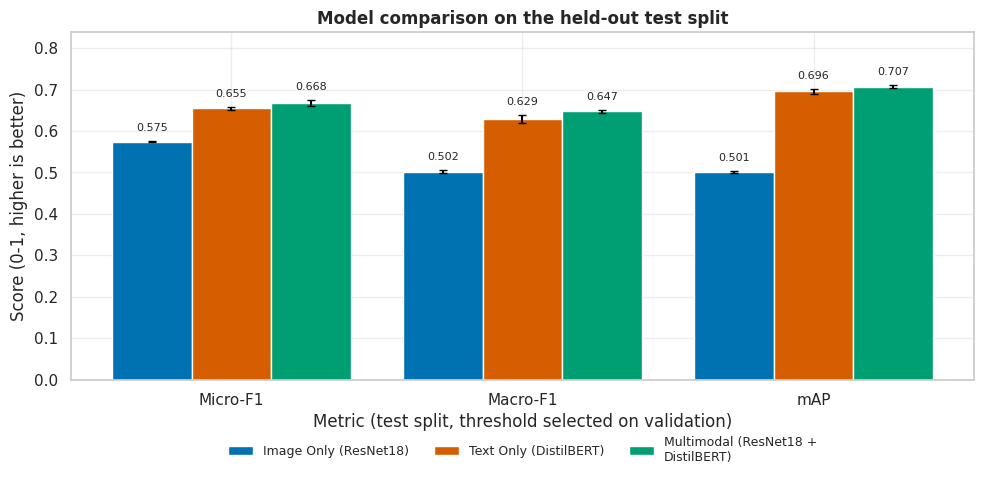

In [40]:
plots.plot_metric_comparison(
    comparison,
    metrics=("micro_f1", "macro_f1", "mAP"),
    save_path=FIGURES / "comparison_metrics.png",
)
plt.show()

In [41]:
# Mean +- std over seeds, and the pairwise deltas that answer RQ3.
aggregated = aggregate_over_seeds(collected, split="test", threshold="selected")
rows = []
for kind, metrics in aggregated.items():
    row = {"model": MODEL_DISPLAY_NAMES[kind], "seeds": metrics["micro_f1"]["n"]}
    for key in ("micro_f1", "macro_f1", "mAP"):
        if key in metrics:
            row[key] = f"{metrics[key]['mean']:.4f} ± {metrics[key]['std']:.4f}"
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))
print()

if {"image", "text", "multimodal"} <= set(aggregated):
    print("RQ3 — multimodal minus the better unimodal system:")
    for key in ("micro_f1", "macro_f1", "mAP"):
        fused = aggregated["multimodal"][key]["mean"]
        best_unimodal_kind = max(("image", "text"), key=lambda k: aggregated[k][key]["mean"])
        best_unimodal = aggregated[best_unimodal_kind][key]["mean"]
        delta = fused - best_unimodal
        spread = max(aggregated[k][key]["std"] for k in ("image", "text", "multimodal"))
        verdict = "larger than the seed spread" if abs(delta) > spread else "WITHIN the seed spread"
        print(f"  {key:9s}: {fused:.4f} - {best_unimodal:.4f} ({best_unimodal_kind})"
              f" = {delta:+.4f}   [{verdict}: max std {spread:.4f}]")

                             model  seeds        micro_f1        macro_f1             mAP
             Image Only (ResNet18)      3 0.5747 ± 0.0005 0.5023 ± 0.0034 0.5007 ± 0.0019
            Text Only (DistilBERT)      3 0.6547 ± 0.0040 0.6288 ± 0.0092 0.6956 ± 0.0053
Multimodal (ResNet18 + DistilBERT)      3 0.6676 ± 0.0066 0.6472 ± 0.0034 0.7071 ± 0.0035

RQ3 — multimodal minus the better unimodal system:
  micro_f1 : 0.6676 - 0.6547 (text) = +0.0129   [larger than the seed spread: max std 0.0066]
  macro_f1 : 0.6472 - 0.6288 (text) = +0.0184   [larger than the seed spread: max std 0.0092]
  mAP      : 0.7071 - 0.6956 (text) = +0.0115   [larger than the seed spread: max std 0.0053]


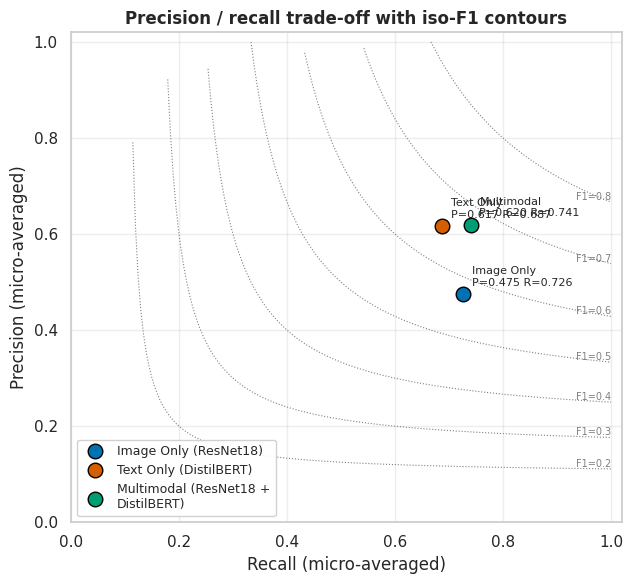

In [42]:
plots.plot_precision_recall_scatter(
    {
        kind: per_seed[PRIMARY_SEED]["test_metrics_selected"]
        for kind, per_seed in collected.items()
        if PRIMARY_SEED in per_seed
    },
    save_path=FIGURES / "comparison_precision_recall.png",
)
plt.show()

### 21.2 Per-genre behaviour (RQ4)

Which genres does fusion actually help? An average improvement could hide a model that gains
on frequent genres and loses on rare ones, so the per-class F1 is reported for every genre and
every system.

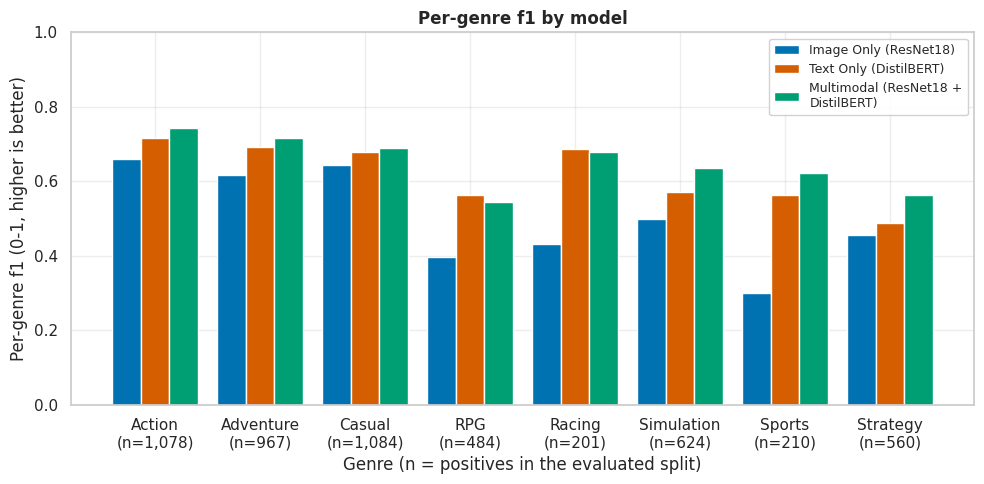

In [43]:
per_class_by_model = {
    kind: per_seed[PRIMARY_SEED]["test_metrics_selected"].get("per_class", {})
    for kind, per_seed in collected.items()
    if PRIMARY_SEED in per_seed
}
plots.plot_per_class_f1(
    per_class_by_model, classes=GENRES, save_path=FIGURES / "comparison_per_class_f1.png"
)
plt.show()

In [44]:
per_class_frame = pd.DataFrame(
    {
        MODEL_DISPLAY_NAMES[kind]: {genre: entry.get("f1") for genre, entry in per_class.items()}
        for kind, per_class in per_class_by_model.items()
    }
).reindex(GENRES)
per_class_frame.insert(
    0,
    "test support",
    [per_class_by_model[next(iter(per_class_by_model))][genre]["support"] for genre in GENRES],
)
if len(per_class_by_model) == 3:
    image_name = MODEL_DISPLAY_NAMES["image"]
    text_name = MODEL_DISPLAY_NAMES["text"]
    fusion_name = MODEL_DISPLAY_NAMES["multimodal"]
    per_class_frame["fusion − best unimodal"] = (
        per_class_frame[fusion_name] - per_class_frame[[image_name, text_name]].max(axis=1)
    )
print("Per-genre F1 on the test split (validation-selected threshold, seed "
      f"{PRIMARY_SEED})")
per_class_frame.sort_values("test support", ascending=False)

Per-genre F1 on the test split (validation-selected threshold, seed 42)


,test support,Image Only (ResNet18),Text Only (DistilBERT),Multimodal (ResNet18 + DistilBERT),fusion − best unimodal
Casual,1084,0.6435,0.6789,0.6885,0.0097
Action,1078,0.6603,0.7157,0.7432,0.0275
Adventure,967,0.6172,0.6918,0.7161,0.0243
Simulation,624,0.4997,0.5712,0.6366,0.0654
Strategy,560,0.4565,0.4870,0.5626,0.0755
RPG,484,0.3959,0.5639,0.5446,-0.0192
Sports,210,0.3003,0.5634,0.6230,0.0596
Racing,201,0.4323,0.6863,0.6776,-0.0087


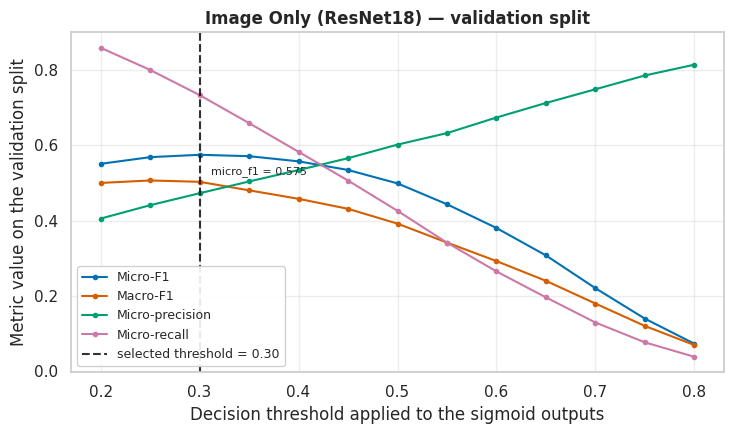

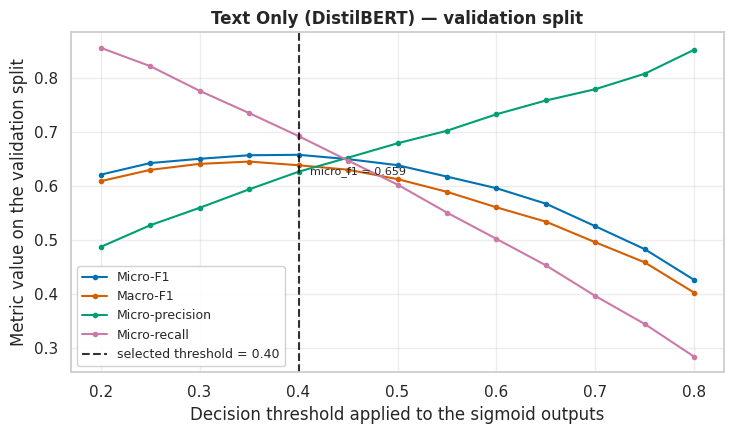

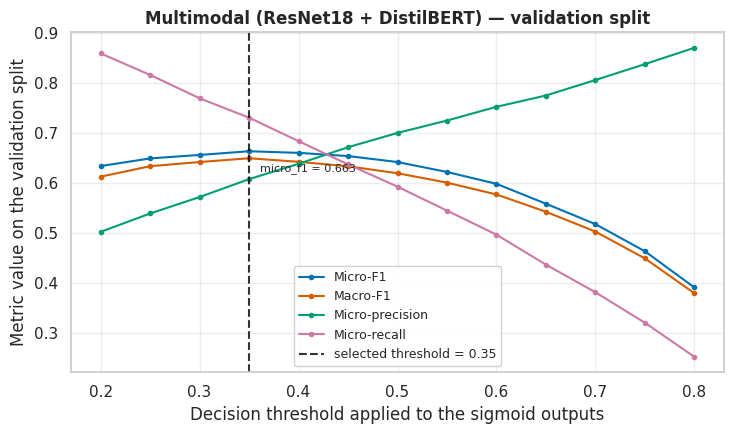

In [45]:
# Threshold analysis — validation only, never test.
for kind, per_seed in collected.items():
    payload = per_seed.get(PRIMARY_SEED)
    if payload is None or not payload.get("threshold_sweep_val"):
        continue
    best = payload["threshold_selected"]
    plots.plot_threshold_analysis(
        pd.DataFrame(payload["threshold_sweep_val"]),
        best_threshold=best if isinstance(best, (int, float)) else None,
        title=f"{MODEL_DISPLAY_NAMES[kind]} — validation split",
        save_path=FIGURES / f"threshold_analysis_{kind}.png",
    )
    plt.show()

In [46]:
# What threshold tuning actually bought, per model.
rows = []
for kind, per_seed in collected.items():
    payload = per_seed.get(PRIMARY_SEED)
    if payload is None:
        continue
    rows.append(
        {
            "model": MODEL_DISPLAY_NAMES[kind],
            "threshold chosen on val": payload["threshold_selected"],
            "val micro-F1 @0.50": payload["val_metrics_default"]["micro_f1"],
            "val micro-F1 @chosen": payload["val_metrics_selected"]["micro_f1"],
            "test micro-F1 @0.50": payload["test_metrics_default"]["micro_f1"],
            "test micro-F1 @chosen": payload["test_metrics_selected"]["micro_f1"],
            "test gain": payload["test_metrics_selected"]["micro_f1"]
            - payload["test_metrics_default"]["micro_f1"],
        }
    )
pd.DataFrame(rows)

,model,threshold chosen on val,val micro-F1 @0.50,val micro-F1 @chosen,test micro-F1 @0.50,test micro-F1 @chosen,test gain
0,Image Only (ResNet18),0.3000,0.4993,0.5753,0.4900,0.5745,0.0845
1,Text Only (DistilBERT),0.4000,0.6394,0.6586,0.6348,0.6503,0.0155
2,Multimodal (ResNet18 + DistilBERT),0.3500,0.6418,0.6634,0.6531,0.6748,0.0217


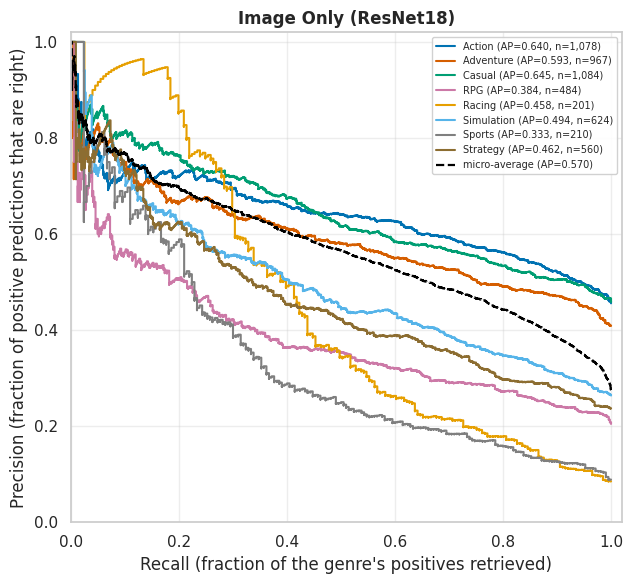

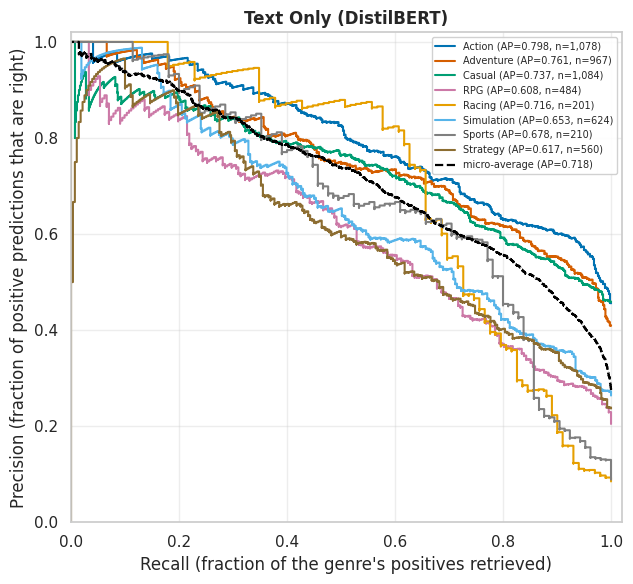

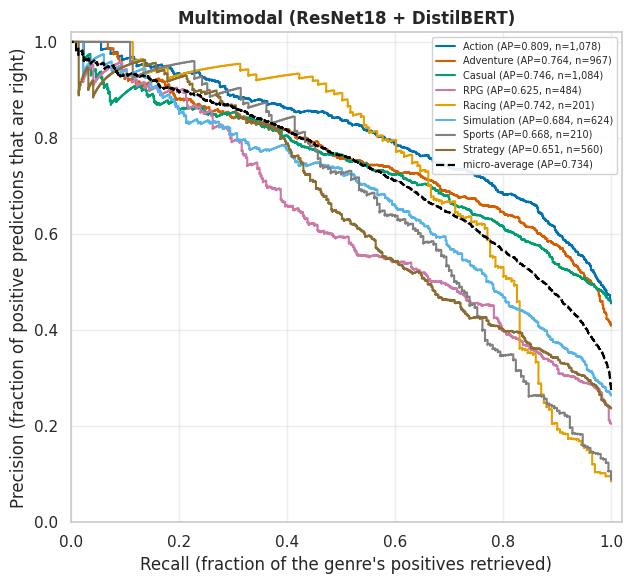

In [47]:
# Precision-recall curves: threshold-free ranking quality per genre.
for kind in collected:
    path = CONFIG.predictions_path(kind, "test", PRIMARY_SEED)
    if not path.is_file():
        continue
    predictions = load_predictions(path)
    plots.plot_pr_curves(
        predictions["labels"],
        predictions["probabilities"],
        classes=GENRES,
        title=MODEL_DISPLAY_NAMES[kind],
        save_path=FIGURES / f"pr_curves_{kind}.png",
    )
    plt.show()

### 21.3 Ablations

Each ablation changes exactly one thing and re-runs the same pipeline, so the effect is
attributable. Only ablations that were actually executed appear below.

| Tag | What changes | Question it answers |
|---|---|---|
| `text_leak` | descriptions keep their titles (`description_clean`) | RQ6 — how much of the text score is title/franchise memorisation? |
| `text_masked` | titles removed **and** explicit genre words masked | how much is literal genre vocabulary? |
| `text_bilstm` | BiLSTM encoder instead of DistilBERT, same tokens | what does pretrained self-attention buy over recurrence? |
| `*_posw` | `--class-weighting pos_weight` for all three systems | does re-weighting the loss beat simply moving the threshold? |
| `multimodal_nonorm` | `--no-normalize-embeddings` | does L2-normalising before fusion matter? |
| `image_finetune` | `layer4` unfrozen + augmentation | what does partial fine-tuning buy at this data size? |

In [48]:
ABLATIONS = {
    "image": "headline — frozen ResNet18",
    "text": "headline — frozen DistilBERT, titles removed",
    "multimodal": "headline — concatenation fusion",
    "text_leak": "RQ6: titles LEFT IN the description",
    "text_masked": "titles removed + genre words masked",
    "text_bilstm": "BiLSTM instead of DistilBERT (same tokens)",
    "image_posw": "image with pos_weight in the loss",
    "text_posw": "text with pos_weight in the loss",
    "multimodal_posw": "multimodal with pos_weight in the loss",
    "multimodal_nonorm": "no L2 normalisation before fusion",
    "image_finetune": "ResNet18 layer4 unfrozen + augmentation",
}
ablation_results = collect_results(model_kinds=list(ABLATIONS), seeds=[PRIMARY_SEED])
rows = []
for kind, description in ABLATIONS.items():
    payload = ablation_results.get(kind, {}).get(PRIMARY_SEED)
    if payload is None:
        continue
    metrics = payload["test_metrics_selected"]
    rows.append(
        {
            "run": kind,
            "what it is": description,
            "micro-F1": metrics["micro_f1"],
            "macro-F1": metrics["macro_f1"],
            "mAP": metrics["mAP"],
            "threshold": payload["threshold_selected"],
        }
    )
ablation_frame = pd.DataFrame(rows)
not_run = [kind for kind in ABLATIONS if kind not in ablation_results]
if not_run:
    print(f"Not executed (therefore not reported): {not_run}")
ablation_frame

,run,what it is,micro-F1,macro-F1,mAP,threshold
0,image,headline — frozen ResNet18,0.5745,0.5007,0.5011,0.3000
1,text,"headline — frozen DistilBERT, titles removed",0.6503,0.6198,0.6960,0.4000
2,multimodal,headline — concatenation fusion,0.6748,0.6490,0.7111,0.3500
3,text_leak,RQ6: titles LEFT IN the description,0.6553,0.6301,0.7063,0.4000
4,text_masked,titles removed + genre words masked,0.6372,0.5841,0.6506,0.3500
5,text_bilstm,BiLSTM instead of DistilBERT (same tokens),0.6069,0.5755,0.6328,0.4000
6,image_posw,image with pos_weight in the loss,0.5305,0.4833,0.4847,0.5000
7,text_posw,text with pos_weight in the loss,0.6512,0.6266,0.6915,0.5000
8,multimodal_posw,multimodal with pos_weight in the loss,0.6569,0.6397,0.7054,0.5500
9,multimodal_nonorm,no L2 normalisation before fusion,0.6624,0.6390,0.7075,0.3000


In [49]:
# The class-imbalance decision, made on VALIDATION and shown with both splits so
# the reader can verify the test set played no part in choosing it.
rows = []
for base in ("image", "text", "multimodal"):
    for tag, label in ((base, "plain BCE (selected)"), (f"{base}_posw", "pos_weight")):
        per_seed = collect_results(model_kinds=[tag], seeds=CONFIG.training.seeds).get(tag, {})
        if not per_seed:
            continue
        val = np.array([p["val_metrics_selected"]["micro_f1"] for p in per_seed.values()])
        test = np.array([p["test_metrics_selected"]["micro_f1"] for p in per_seed.values()])
        card = np.mean([p["test_metrics_selected"]["label_cardinality_pred"]
                        for p in per_seed.values()])
        amap = np.array([p["test_metrics_selected"]["mAP"] for p in per_seed.values()])
        rows.append({
            "system": MODEL_DISPLAY_NAMES[base],
            "loss": label,
            "seeds": len(val),
            "VAL micro-F1": f"{val.mean():.4f}",
            "test micro-F1": f"{test.mean():.4f}",
            "test mAP": f"{amap.mean():.4f}",
            "predicted genres/game": round(float(card), 2),
        })
if rows:
    print("Selection rule: highest VALIDATION micro-F1. True genres per game = "
          f"{load_json(CONFIG.metrics_path('multimodal', PRIMARY_SEED))['test_metrics_selected']['label_cardinality_true']:.2f}")
    display(pd.DataFrame(rows))

Selection rule: highest VALIDATION micro-F1. True genres per game = 2.20


,system,loss,seeds,VAL micro-F1,test micro-F1,test mAP,predicted genres/game
0,Image Only (ResNet18),plain BCE (selected),3,0.5733,0.5747,0.5007,3.4000
1,Image Only (ResNet18),pos_weight,3,0.5380,0.5379,0.4849,3.4700
2,Text Only (DistilBERT),plain BCE (selected),3,0.6568,0.6547,0.6956,2.4600
3,Text Only (DistilBERT),pos_weight,3,0.6360,0.6426,0.6836,2.6100
4,Multimodal (ResNet18 + DistilBERT),plain BCE (selected),3,0.6610,0.6676,0.7071,2.7000
5,Multimodal (ResNet18 + DistilBERT),pos_weight,3,0.6452,0.6539,0.6992,2.5000


In [50]:
# RQ6 in one place: what happens when titles are left in the text.
if {"text", "text_leak"} <= set(ablation_results):
    clean = ablation_results["text"][PRIMARY_SEED]["test_metrics_selected"]
    leaky = ablation_results["text_leak"][PRIMARY_SEED]["test_metrics_selected"]
    masked = (
        ablation_results.get("text_masked", {}).get(PRIMARY_SEED, {}).get("test_metrics_selected")
    )
    print("RQ6 — text-only model, identical in every respect except the description variant")
    print(f"{'variant':38s} {'micro-F1':>9s} {'macro-F1':>9s} {'mAP':>9s}")
    print(f"{'titles left in (description_clean)':38s} {leaky['micro_f1']:9.4f}"
          f" {leaky['macro_f1']:9.4f} {leaky['mAP']:9.4f}")
    print(f"{'titles removed (headline setting)':38s} {clean['micro_f1']:9.4f}"
          f" {clean['macro_f1']:9.4f} {clean['mAP']:9.4f}")
    if masked:
        print(f"{'titles removed + genre words masked':38s} {masked['micro_f1']:9.4f}"
              f" {masked['macro_f1']:9.4f} {masked['mAP']:9.4f}")
    print()
    print(f"cost of removing titles      : {clean['micro_f1'] - leaky['micro_f1']:+.4f} micro-F1")
    if masked:
        print(f"cost of masking genre words  : {masked['micro_f1'] - clean['micro_f1']:+.4f} micro-F1")

RQ6 — text-only model, identical in every respect except the description variant
variant                                 micro-F1  macro-F1       mAP
titles left in (description_clean)        0.6553    0.6301    0.7063
titles removed (headline setting)         0.6503    0.6198    0.6960
titles removed + genre words masked       0.6372    0.5841    0.6506

cost of removing titles      : -0.0051 micro-F1
cost of masking genre words  : -0.0130 micro-F1


## 22. Explainability — Grad-CAM on the vision branch

Aggregate metrics tell us *how often* Model A is right, not *what it looked at*. Grad-CAM
(Selvaraju et al., 2017) answers the second question without modifying the network:

1. take the activations $A^k$ of the last convolutional stage (`ResNet18.layer4`, a
   $512\times7\times7$ tensor for a $224^2$ input);
2. backpropagate the chosen genre's **logit** to get $\partial y^c / \partial A^k$;
3. average those gradients over space to obtain one importance weight per channel,
   $\alpha^c_k = \frac{1}{HW}\sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$;
4. form $L^c = \mathrm{ReLU}\big(\sum_k \alpha^c_k A^k\big)$ and upsample to input size.

Two implementation details matter and are easy to get wrong:

* the score differentiated is the **logit**, not the sigmoid probability — a saturated sigmoid
  has a vanishing derivative, so a confidently predicted genre would produce an almost blank
  map;
* the ReLU keeps only *positive* contributions, so the map shows evidence **for** the genre.

A caveat to keep in view while reading the panels below: Grad-CAM shows where the evidence the
network used is located, at 7×7 resolution upsampled to 224×224. It is a coarse correlational
attribution, not a causal explanation, and it says nothing at all about the text branch.

In [51]:
from gamesense.inference.predictor import GameSensePredictor, MissingCheckpointError

predictor = GameSensePredictor(seed=PRIMARY_SEED)
print("checkpoints available:", predictor.available_models())

checkpoints available: {'image': True, 'text': True, 'multimodal': True}


In [52]:
# Explain a handful of real test-split screenshots, chosen to include both
# successes and failures rather than only the flattering cases.
from gamesense.evaluation.error_analysis import build_error_frame, select_examples

test_predictions = None
error_frames = {}
for kind in MODEL_KINDS:
    path = CONFIG.predictions_path(kind, "test", PRIMARY_SEED)
    if not path.is_file():
        continue
    payload = collected[kind][PRIMARY_SEED]
    threshold = payload["threshold_selected"]
    predictions = load_predictions(path)
    error_frames[kind] = build_error_frame(
        labels=predictions["labels"],
        probabilities=predictions["probabilities"],
        sample_ids=predictions["sample_ids"],
        samples=pd.concat(list(bundle.splits.values()), ignore_index=True),
        games=games,
        threshold=np.asarray(threshold) if isinstance(threshold, list) else float(threshold),
        classes=GENRES,
    )
print({kind: len(frame) for kind, frame in error_frames.items()})

{'image': 2365, 'text': 2365, 'multimodal': 2365}


11:05:36 | INFO    | gamesense.models.image       | ImageEncoder(resnet18, pretrained=True, frozen=True, unfrozen_stages=0)


11:05:36 | INFO    | gamesense.inference.predictor | Loaded image model from image_model.pt


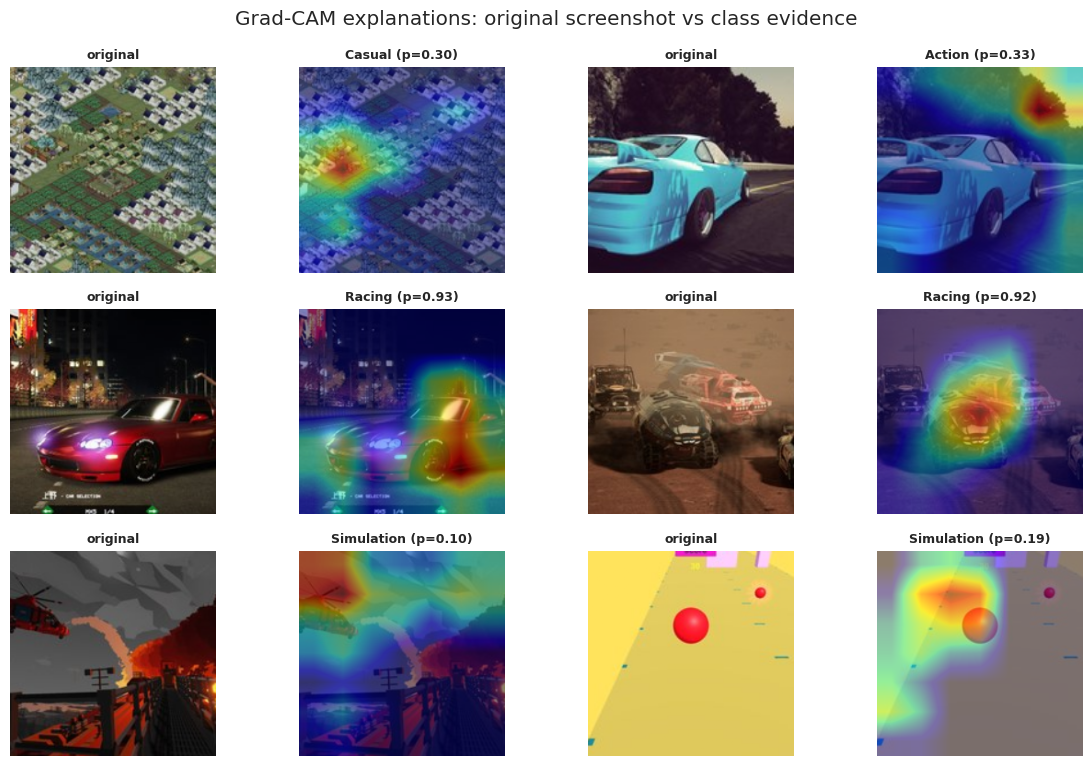

In [53]:
gradcam_results = []
if "image" in error_frames and predictor.available_models().get("image"):
    chosen = select_examples(error_frames["image"], n_per_outcome=2, seed=PRIMARY_SEED)
    for row in chosen.head(6).to_dict("records"):
        image_path = CONFIG.paths.root / str(row["image_path"])
        if not image_path.is_file():
            continue
        target_genre = (row["true_genres"].split("|") or [None])[0] or None
        try:
            explanation = predictor.explain(image=image_path, mode="image", genre=target_genre)
        except Exception as error:
            print(f"Grad-CAM failed for {row['sample_id']}: {error}")
            continue
        explanation.title = (
            f"{str(row.get('name'))[:34]}  [{row['outcome']}]\n"
            f"true: {row['true_genres'].replace('|', ', ')}\n"
            f"pred: {row['pred_genres'].replace('|', ', ') or '(none)'}"
        )
        gradcam_results.append(explanation)

if gradcam_results:
    plots.plot_gradcam_grid(
        gradcam_results, ncols=2, save_path=FIGURES / "gradcam_examples.png"
    )
    plt.show()
else:
    print("No Grad-CAM examples produced (image model not trained, or images unavailable).")

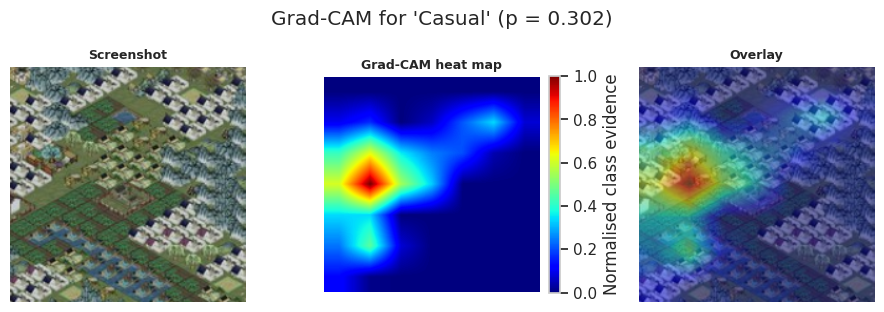

explained genre : Casual
probability     : 0.3016
heatmap shape   : (224, 224), range [0.00, 1.00]


In [54]:
# A single example at full size, with the explained genre and its probability.
if gradcam_results:
    first = gradcam_results[0]
    plots.plot_gradcam(
        first.base_image,
        first.heatmap,
        first.overlay,
        title=f"Grad-CAM for '{first.genre}' (p = {first.probability:.3f})",
        save_path=FIGURES / "gradcam_single.png",
    )
    plt.show()
    print(f"explained genre : {first.genre}")
    print(f"probability     : {first.probability:.4f}")
    print(f"heatmap shape   : {first.heatmap.shape}, range "
          f"[{first.heatmap.min():.2f}, {first.heatmap.max():.2f}]")

In [55]:
# Where does the attention mass actually fall? A crude but honest summary:
# how concentrated is each heat map, and in which third of the frame does it peak?
if gradcam_results:
    rows = []
    for result in gradcam_results:
        heat = result.heatmap
        height, width = heat.shape
        vertical_thirds = [heat[: height // 3], heat[height // 3 : 2 * height // 3], heat[2 * height // 3 :]]
        peak_row, peak_col = np.unravel_index(int(np.argmax(heat)), heat.shape)
        rows.append(
            {
                "explained genre": result.genre,
                "p": round(result.probability, 3),
                "share of mass in top 10% of pixels": round(
                    float(np.sort(heat.ravel())[-int(0.1 * heat.size):].sum() / max(heat.sum(), 1e-9)), 3
                ),
                "peak position (row, col)": f"({peak_row}, {peak_col})",
                "band with most mass": ["top", "middle", "bottom"][
                    int(np.argmax([band.sum() for band in vertical_thirds]))
                ],
            }
        )
    display(pd.DataFrame(rows))

,explained genre,p,share of mass in top 10% of pixels,"peak position (row, col)",band with most mass
0,Casual,0.3020,0.4210,"(111, 47)",middle
1,Action,0.3310,0.3410,"(47, 176)",top
2,Racing,0.9290,0.2940,"(175, 175)",bottom
3,Racing,0.9210,0.4220,"(112, 112)",middle
4,Simulation,0.1000,0.3270,"(47, 47)",top
5,Simulation,0.1900,0.3940,"(48, 80)",top


**What the heat maps actually show.** Reading the panels above, three patterns recur.

1. **Scene, not object.** For several vehicle screenshots the map explaining *Action* or
   *Racing* concentrates on the road, cliff, sky or palm trees rather than on the car itself.
   The network is keying on *where the game takes place* more than on the diagnostic object.
   That is consistent with an ImageNet-pretrained backbone whose features were optimised for
   scene and texture statistics, and it plausibly explains Model A's weak Racing and Sports
   scores: those genres are defined by an object and a rule set, not by a landscape.
2. **Layout for the "management" genres.** On isometric town/base screenshots the map spreads
   over the tiled grid rather than concentrating anywhere, which is the visual signature the
   model appears to use for Casual and Simulation — the genres where Model A is strongest.
3. **Confident attention on weak evidence.** Some panels show a crisp, well-localised heat map
   attached to a low probability. Grad-CAM shows *where* the evidence the network used is
   located; it says nothing about whether that evidence was any good.

Two cautions belong with these figures. Grad-CAM is a **correlational** attribution at 7×7
resolution upsampled to 224×224 — it localises, it does not explain causally, and a
convincing-looking map is not evidence that the model reasoned correctly. And it covers the
**vision branch only**: nothing here explains what the text branch or the fusion MLP did, which
is a real gap given that text is the stronger modality in this study.

## 23. Error analysis

Rather than picking illustrative failures by hand, every prediction on the test split is
classified into one of four outcomes and then sliced along variables that might explain the
errors.

| Outcome | Meaning |
|---|---|
| `exact` | the predicted label set equals the true label set |
| `partial` | non-empty overlap, but not identical |
| `wrong` | a non-empty prediction with **zero** overlap |
| `empty_prediction` | no genre passed the threshold at all |

In [56]:
outcome_table = pd.DataFrame(
    {
        MODEL_DISPLAY_NAMES[kind]: frame["outcome"].value_counts(normalize=True)
        for kind, frame in error_frames.items()
    }
).reindex(["exact", "partial", "wrong", "empty_prediction"]).fillna(0.0)
print("Share of test samples by outcome")
outcome_table

Share of test samples by outcome


,Image Only (ResNet18),Text Only (DistilBERT),Multimodal (ResNet18 + DistilBERT)
outcome,,,
exact,0.0630,0.1776,0.1776
partial,0.8588,0.7645,0.7755
wrong,0.0782,0.0571,0.0469
empty_prediction,0.0000,0.0008,0.0000


In [57]:
# Mean set-overlap (Jaccard) per model - a single-number summary of partial credit.
pd.DataFrame(
    {
        "model": [MODEL_DISPLAY_NAMES[k] for k in error_frames],
        "mean Jaccard": [frame["jaccard"].mean() for frame in error_frames.values()],
        "mean false positives / sample": [frame["fp"].mean() for frame in error_frames.values()],
        "mean missed genres / sample": [frame["fn"].mean() for frame in error_frames.values()],
    }
)

,model,mean Jaccard,mean false positives / sample,mean missed genres / sample
0,Image Only (ResNet18),0.4273,1.7670,0.6025
1,Text Only (DistilBERT),0.5301,0.9400,0.6884
2,Multimodal (ResNet18 + DistilBERT),0.5484,1.0021,0.5704


### 23.1 Which genres are confused with which

Multi-label confusion is not a single matrix. The table below counts, for every ordered pair
$(i, j)$, how often genre $j$ was predicted for a game whose true label set contains $i$ but
**not** $j$ — i.e. a genuine cross-genre false positive. The diagonal holds per-genre recall.

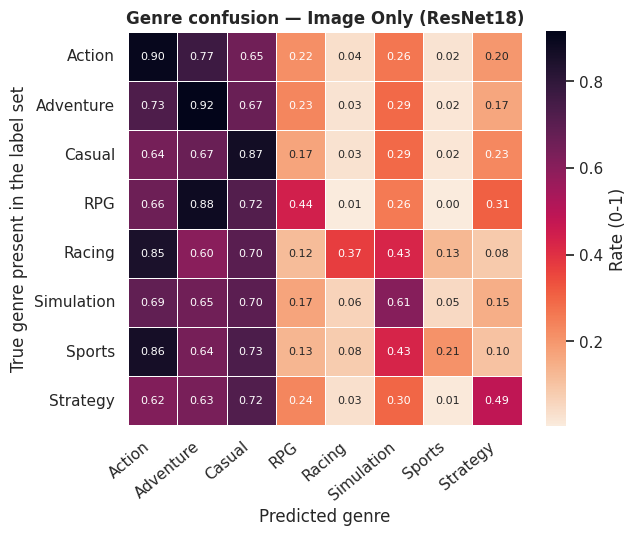

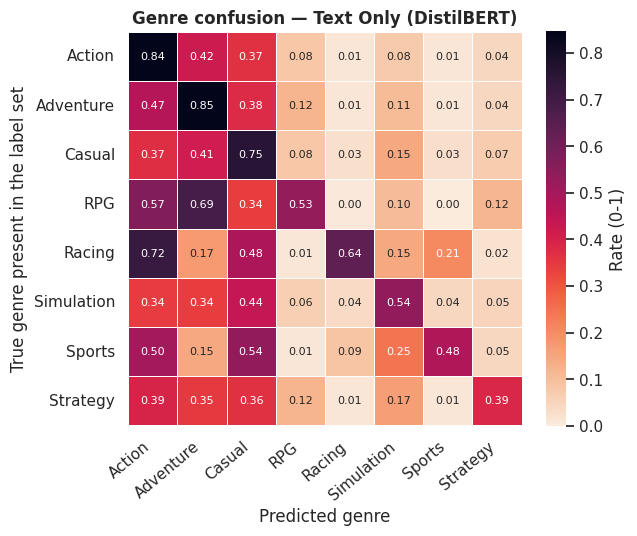

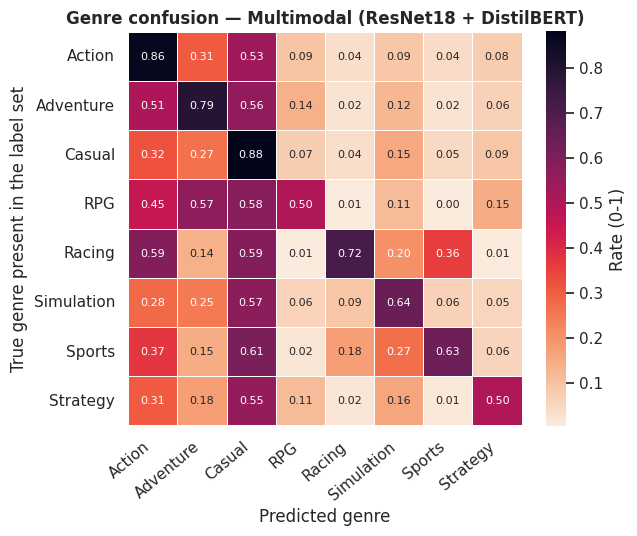

In [58]:
from gamesense.evaluation.error_analysis import (
    co_occurrence_confusion,
    confusion_pairs,
    grouped_error_rates,
    per_class_error_summary,
)

for kind in error_frames:
    predictions = load_predictions(CONFIG.predictions_path(kind, "test", PRIMARY_SEED))
    threshold = collected[kind][PRIMARY_SEED]["threshold_selected"]
    matrix = confusion_pairs(
        labels=predictions["labels"],
        probabilities=predictions["probabilities"],
        threshold=np.asarray(threshold) if isinstance(threshold, list) else float(threshold),
        classes=GENRES,
    )
    plots.plot_confusion_heatmap(
        matrix,
        title=f"Genre confusion — {MODEL_DISPLAY_NAMES[kind]}",
        save_path=FIGURES / f"confusion_{kind}.png",
    )
    plt.show()

In [59]:
# The most frequent substitution: "the model missed X and predicted Y instead".
best_kind = "multimodal" if "multimodal" in error_frames else next(iter(error_frames))
print(f"Most common substitutions — {MODEL_DISPLAY_NAMES[best_kind]}")
co_occurrence_confusion(error_frames[best_kind], top_k=12)

Most common substitutions — Multimodal (ResNet18 + DistilBERT)


,true_genre_missed,predicted_instead,count
0,RPG,Casual,107
1,Strategy,Casual,82
2,Simulation,Casual,69
3,Adventure,Casual,64
4,Strategy,Adventure,63
5,Strategy,Action,62
6,Simulation,Action,59
7,Action,Casual,56
8,RPG,Action,53
9,RPG,Adventure,49


In [60]:
print(f"Per-genre error breakdown — {MODEL_DISPLAY_NAMES[best_kind]}")
predictions = load_predictions(CONFIG.predictions_path(best_kind, "test", PRIMARY_SEED))
threshold = collected[best_kind][PRIMARY_SEED]["threshold_selected"]
per_class_error_summary(
    labels=predictions["labels"],
    probabilities=predictions["probabilities"],
    threshold=np.asarray(threshold) if isinstance(threshold, list) else float(threshold),
    classes=GENRES,
)

Per-genre error breakdown — Multimodal (ResNet18 + DistilBERT)


,genre,support,tp,fp,fn,tn,precision,recall,f1,false_negative_rate,false_positive_rate
0,Casual,1084,955,735,129,546,0.5651,0.8810,0.6885,0.1190,0.5738
1,Action,1078,932,498,146,789,0.6517,0.8646,0.7432,0.1354,0.3869
2,Adventure,967,768,410,199,988,0.6520,0.7942,0.7161,0.2058,0.2933
3,Simulation,624,402,237,222,1504,0.6291,0.6442,0.6366,0.3558,0.1361
4,Strategy,560,281,158,279,1647,0.6401,0.5018,0.5626,0.4982,0.0875
5,RPG,484,244,168,240,1713,0.5922,0.5041,0.5446,0.4959,0.0893
6,Sports,210,133,84,77,2071,0.6129,0.6333,0.6230,0.3667,0.0390
7,Racing,201,144,80,57,2084,0.6429,0.7164,0.6776,0.2836,0.0370


### 23.2 What makes a game hard?

Four candidate explanations are tested against the data: the number of true genres, the length
of the description, and the brightness and contrast of the screenshot (a proxy for menus,
cinematics and dark night scenes).

In [61]:
from gamesense.evaluation.error_analysis import enrich_with_image_stats

IMAGE_STAT_LIMIT = 1200  # opening every JPEG is slow; a sample is enough
enriched = {
    kind: enrich_with_image_stats(frame, config=CONFIG, limit=IMAGE_STAT_LIMIT)
    for kind, frame in error_frames.items()
}
print(f"Image statistics computed for the first {IMAGE_STAT_LIMIT} test samples per model.")

Image statistics computed for the first 1200 test samples per model.


Prediction quality by number of TRUE genres — Multimodal (ResNet18 + DistilBERT)


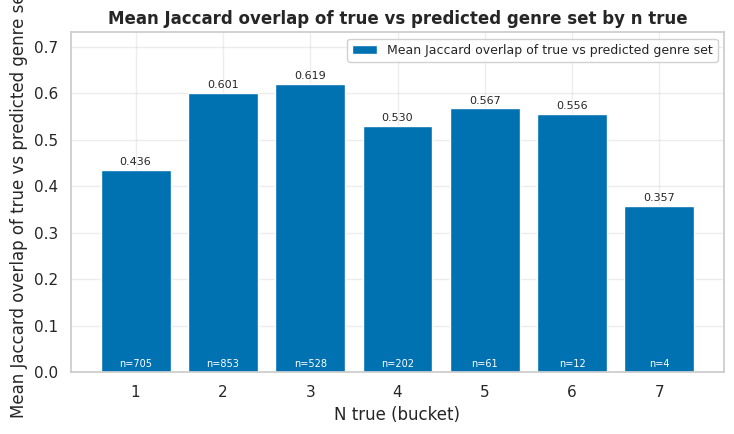

,n_true,n,mean_jaccard,exact_rate,wrong_rate,empty_rate,mean_fp,mean_fn
0,1,705,0.4358,0.1191,0.1064,0.0000,1.4766,0.1064
1,2,853,0.6013,0.2497,0.0258,0.0000,0.9543,0.3951
2,3,528,0.6195,0.2027,0.0208,0.0000,0.6989,0.8258
3,4,202,0.5301,0.0693,0.0149,0.0000,0.6040,1.6386
4,5,61,0.5673,0.0328,0.0000,0.0000,0.3934,1.9672
5,6,12,0.5556,0.0000,0.0000,0.0000,0.0000,2.6667
6,7,4,0.3571,0.0000,0.0000,0.0000,0.0000,4.5000


In [62]:
print(f"Prediction quality by number of TRUE genres — {MODEL_DISPLAY_NAMES[best_kind]}")
by_labels = grouped_error_rates(enriched[best_kind], by="n_true")
plots.plot_error_rate_by_group(
    by_labels, x="n_true", save_path=FIGURES / f"error_by_n_labels_{best_kind}.png"
)
plt.show()
by_labels

Prediction quality by DESCRIPTION LENGTH (words) — Multimodal (ResNet18 + DistilBERT)


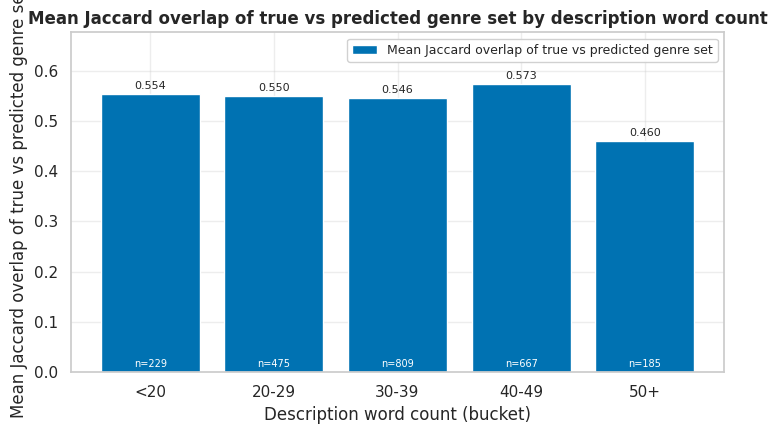

,description_word_count,n,mean_jaccard,exact_rate,wrong_rate,empty_rate,mean_fp,mean_fn
0,<20,229,0.5540,0.2009,0.0655,0.0000,0.8996,0.6725
1,20-29,475,0.5495,0.1979,0.0589,0.0000,0.9705,0.5242
2,30-39,809,0.5463,0.1607,0.0433,0.0000,0.9988,0.5587
3,40-49,667,0.5728,0.1889,0.0255,0.0000,0.9685,0.5727
4,50+,185,0.4602,0.1297,0.0865,0.0000,1.3459,0.6054


In [63]:
DESCRIPTION_BINS = [0, 20, 30, 40, 50, 10_000]
DESCRIPTION_LABELS = ["<20", "20-29", "30-39", "40-49", "50+"]
print(f"Prediction quality by DESCRIPTION LENGTH (words) — {MODEL_DISPLAY_NAMES[best_kind]}")
by_length = grouped_error_rates(
    enriched[best_kind], by="description_word_count",
    bins=DESCRIPTION_BINS, labels=DESCRIPTION_LABELS,
)
plots.plot_error_rate_by_group(
    by_length, x="description_word_count",
    save_path=FIGURES / f"error_by_description_length_{best_kind}.png",
)
plt.show()
by_length

Prediction quality by SCREENSHOT BRIGHTNESS — Image Only (ResNet18)


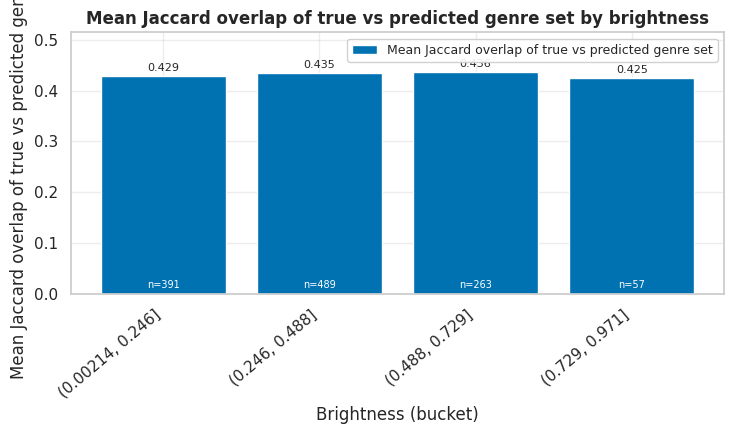

,brightness,n,mean_jaccard,exact_rate,wrong_rate,empty_rate,mean_fp,mean_fn
0,"(0.00214, 0.246]",391,0.4286,0.0691,0.0972,0.0000,1.6624,0.6036
1,"(0.246, 0.488]",489,0.4354,0.0634,0.0573,0.0000,1.7853,0.6053
2,"(0.488, 0.729]",263,0.4361,0.0608,0.0646,0.0000,1.7795,0.5894
3,"(0.729, 0.971]",57,0.4251,0.1228,0.1228,0.0000,1.5614,0.5088


...and by screenshot CONTRAST (low contrast = menus, loading screens, fog):


,contrast,n,mean_jaccard,exact_rate,wrong_rate,empty_rate,mean_fp,mean_fn
0,"(0.00714, 0.129]",255,0.4213,0.0745,0.1059,0.0000,1.6314,0.6706
1,"(0.129, 0.249]",755,0.4359,0.0702,0.0702,0.0000,1.7762,0.5801
2,"(0.249, 0.368]",180,0.4325,0.0444,0.0556,0.0000,1.7111,0.5778
3,"(0.368, 0.488]",10,0.5067,0.1000,0.0000,0.0000,1.5000,0.3000


In [64]:
print(f"Prediction quality by SCREENSHOT BRIGHTNESS — {MODEL_DISPLAY_NAMES.get('image', 'image')}")
image_kind = "image" if "image" in enriched else best_kind
if enriched[image_kind]["brightness"].notna().any():
    by_brightness = grouped_error_rates(enriched[image_kind], by="brightness", bins=4)
    plots.plot_error_rate_by_group(
        by_brightness, x="brightness",
        save_path=FIGURES / f"error_by_brightness_{image_kind}.png",
    )
    plt.show()
    display(by_brightness)
    by_contrast = grouped_error_rates(enriched[image_kind], by="contrast", bins=4)
    print("...and by screenshot CONTRAST (low contrast = menus, loading screens, fog):")
    display(by_contrast)
else:
    print("No image statistics available.")

### 23.3 Qualitative examples: successes, partial matches and failures

The panels below are drawn with the same rule for every outcome class, so the failures are as
representative as the successes.

C:\Users\User\Desktop\Multimodal AI for Video Game Understanding\src\gamesense\visualization\plots.py:1883: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0.04, 1, 0.97))
C:\Users\User\Desktop\Multimodal AI for Video Game Understanding\src\gamesense\visualization\plots.py:1883: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0.04, 1, 0.97))
C:\Users\User\Desktop\Multimodal AI for Video Game Understanding\src\gamesense\visualization\plots.py:1883: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0.04, 1, 0.97))


C:\Users\User\Desktop\Multimodal AI for Video Game Understanding\src\gamesense\visualization\plots.py:291: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.savefig(target, dpi=dpi, bbox_inches="tight")
C:\Users\User\Desktop\Multimodal AI for Video Game Understanding\src\gamesense\visualization\plots.py:291: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(target, dpi=dpi, bbox_inches="tight")
C:\Users\User\Desktop\Multimodal AI for Video Game Understanding\src\gamesense\visualization\plots.py:291: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.savefig(target, dpi=dpi, bbox_inches="tight")


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


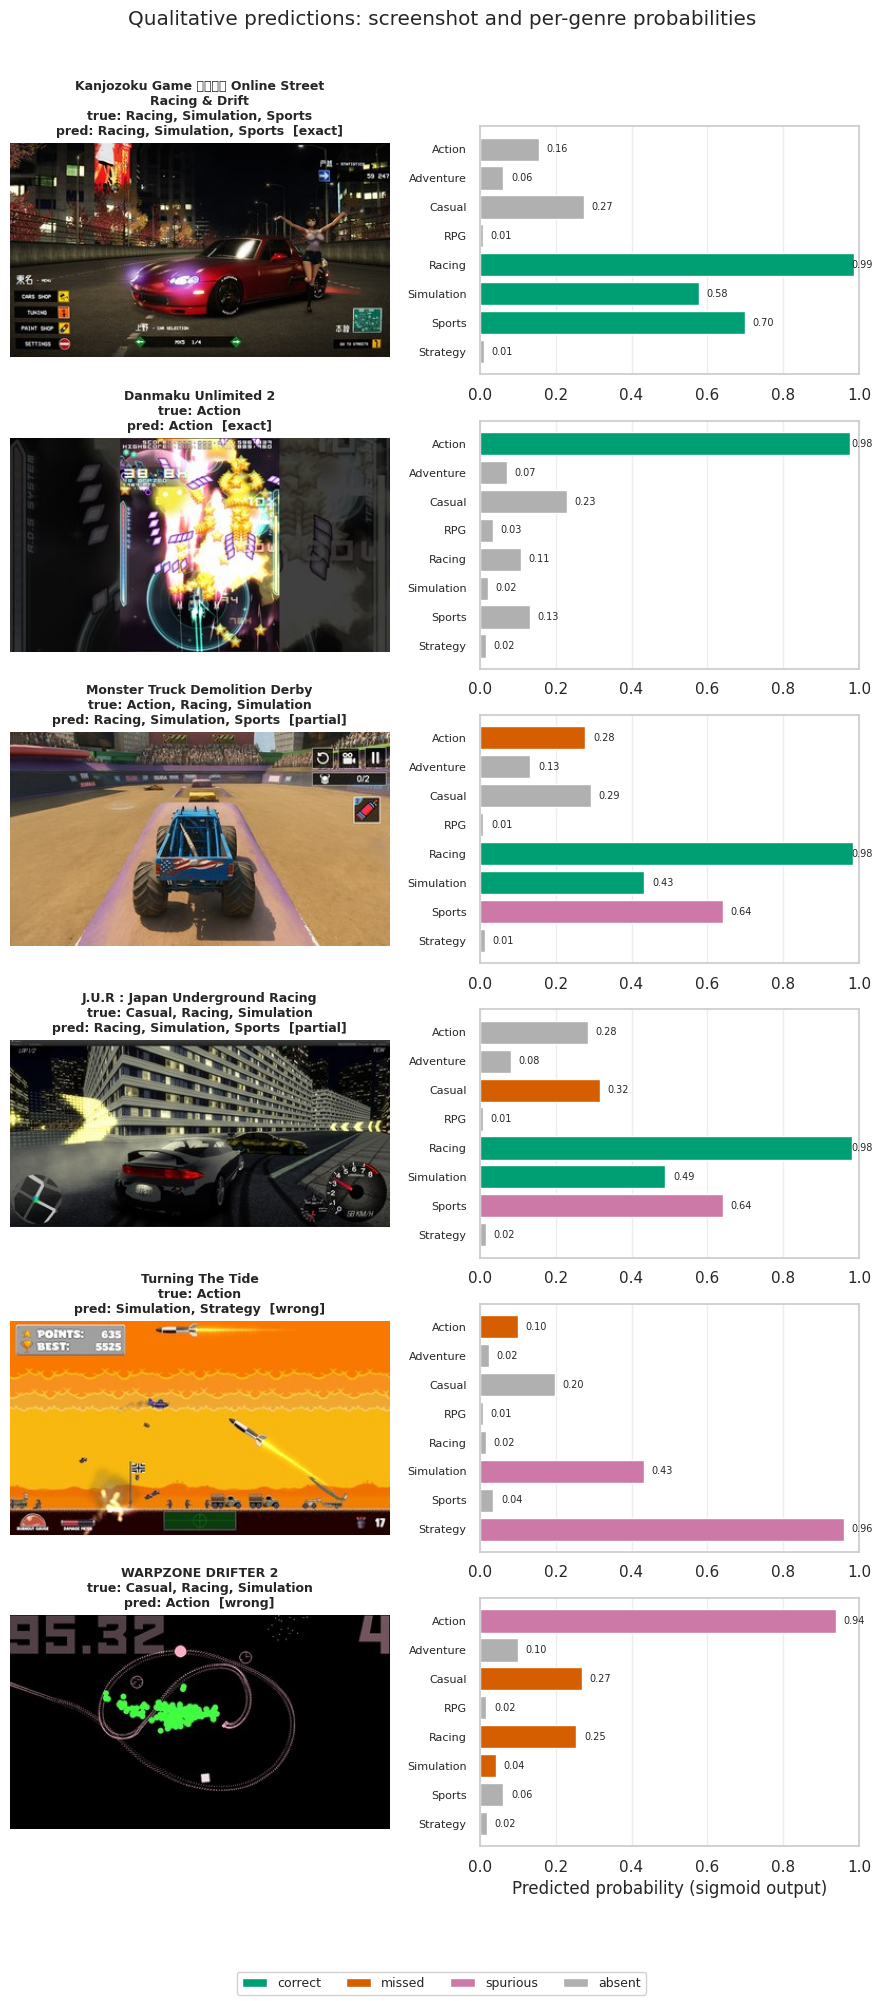

In [65]:
examples = select_examples(error_frames[best_kind], n_per_outcome=2, seed=PRIMARY_SEED)
plots.plot_prediction_examples(
    examples, root=CONFIG.paths.root, n=min(8, len(examples)),
    classes=GENRES, save_path=FIGURES / f"prediction_examples_{best_kind}.png",
)
plt.show()

In [66]:
# The same examples in text form, so the description can be read alongside the image.
columns = [c for c in ("name", "outcome", "true_genres", "pred_genres", "missed_genres",
                       "spurious_genres", "jaccard", "description_word_count") if c in examples.columns]
display(examples[columns])
print()
for _, row in examples.head(4).iterrows():
    print(f"--- {row.get('name')}  [{row['outcome']}]")
    print(f"    true : {row['true_genres'].replace('|', ', ')}")
    print(f"    pred : {row['pred_genres'].replace('|', ', ') or '(none)'}")
    print(f"    text : {str(row.get('description', ''))[:200]}")
    print()

,name,outcome,true_genres,pred_genres,missed_genres,spurious_genres,jaccard,description_word_count
0,Kanjozoku Game レーサー Online Street Racing & Drift,exact,Racing|Simulation|Sports,Racing|Simulation|Sports,,,1.0000,20
1,Danmaku Unlimited 2,exact,Action,Action,,,1.0000,37
2,Monster Truck Demolition Derby,partial,Action|Racing|Simulation,Racing|Simulation|Sports,Action,Sports,0.5000,39
3,J.U.R : Japan Underground Racing,partial,Casual|Racing|Simulation,Racing|Simulation|Sports,Casual,Sports,0.5000,24
4,Turning The Tide,wrong,Action,Simulation|Strategy,Action,Simulation|Strategy,0.0000,53
5,WARPZONE DRIFTER 2,wrong,Casual|Racing|Simulation,Action,Casual|Racing|Simulation,Action,0.0000,16



--- Kanjozoku Game レーサー Online Street Racing & Drift  [exact]
    true : Racing, Simulation, Sports
    pred : Racing, Simulation, Sports
    text : 90s Osaka Kanjo Night Street Racing and Drift Online with True JDM Cars, Online PvP, Engine, Body and Suspension Tuning!

--- Danmaku Unlimited 2  [exact]
    true : Action
    pred : Action
    text : Classic Japanese style vertical manic shooting action! Shoot, dodge and explode your way through the second entry in the critically acclaimed Danmaku Unlimited series. Battle through nail-biting bulle

--- Monster Truck Demolition Derby  [partial]
    true : Action, Racing, Simulation
    pred : Racing, Simulation, Sports
    text : The battle of monster truck and monster car in stunt games begins. Welcome to the Demolition Derby Truck Stunts monster games. Monster truck simulator games are free monster car games. Monster truck g

--- J.U.R : Japan Underground Racing  [partial]
    true : Casual, Racing, Simulation
    pred : Racing, Simula

### 23.4 RQ5/RQ6 — where the modalities disagree, and the leakage experiment

If fusion is doing real work, there should be samples the fused model gets right that *both*
unimodal models get wrong. The comparison below counts exactly that, per sample.

In [67]:
from gamesense.evaluation.error_analysis import compare_model_errors

if len(error_frames) == 3:
    agreement = compare_model_errors(error_frames)
    total = len(agreement)
    means = {m: agreement[f"jaccard_{m}"].mean() for m in ("image", "text", "multimodal")}
    print("mean per-sample Jaccard: image %.4f | text %.4f | multimodal %.4f"
          % (means["image"], means["text"], means["multimodal"]))
    print()

    # Two different comparisons, with two different answers. Only the first one
    # answers RQ3; the second is context, because no single deployable model
    # achieves the per-sample oracle.
    best_single = "text" if means["text"] >= means["image"] else "image"
    single = agreement[f"jaccard_{best_single}"]
    oracle = agreement[["jaccard_image", "jaccard_text"]].max(axis=1)

    for label, baseline in (
        (f"the best SINGLE unimodal model ({best_single})", single),
        ("a per-sample ORACLE over both unimodal models", oracle),
    ):
        better = int((agreement["jaccard_multimodal"] > baseline).sum())
        worse = int((agreement["jaccard_multimodal"] < baseline).sum())
        same = total - better - worse
        print(f"Fusion vs {label}:")
        print(f"   better   : {better:5,} ({100*better/total:5.1f}%)")
        print(f"   worse    : {worse:5,} ({100*worse/total:5.1f}%)")
        print(f"   unchanged: {same:5,} ({100*same/total:5.1f}%)")
        print(f"   net      : {better - worse:+,} samples")
        print()
    print(f"mean Jaccard of the oracle: {oracle.mean():.4f} "
          "(an upper bound no single model reaches, which is why fusion loses to it)")
    print()
    print("Examples the fused model FIXED relative to the best single model:")
    display(
        agreement.loc[
            agreement["jaccard_multimodal"] > single,
            ["sample_id", "true_genres", "pred_genres_image", "pred_genres_text",
             "pred_genres_multimodal"],
        ].head(8)
    )
    print("Examples the fused model BROKE relative to the best single model:")
    display(
        agreement.loc[
            agreement["jaccard_multimodal"] < single,
            ["sample_id", "true_genres", "pred_genres_image", "pred_genres_text",
             "pred_genres_multimodal"],
        ].head(6)
    )

mean per-sample Jaccard: image 0.4273 | text 0.5301 | multimodal 0.5484

Fusion vs the best SINGLE unimodal model (text):
   better   :   666 ( 28.2%)
   worse    :   537 ( 22.7%)
   unchanged: 1,162 ( 49.1%)
   net      : +129 samples

Fusion vs a per-sample ORACLE over both unimodal models:
   better   :   406 ( 17.2%)
   worse    :   872 ( 36.9%)
   unchanged: 1,087 ( 46.0%)
   net      : -466 samples

mean Jaccard of the oracle: 0.6047 (an upper bound no single model reaches, which is why fusion loses to it)

Examples the fused model FIXED relative to the best single model:


,sample_id,true_genres,pred_genres_image,pred_genres_text,pred_genres_multimodal
0,1001590_0,Action|Casual,Action|Adventure|Casual|RPG,Action|Adventure|Casual,Action|Casual
1,1001590_1,Action|Casual,Action|Adventure|Casual|RPG|Strategy,Action|Adventure|Casual,Action|Casual
4,1004790_0,Adventure|Casual|RPG,Casual|Simulation|Strategy,Action|Adventure|RPG,Action|Adventure|Casual|RPG|Simulation
5,1004790_1,Adventure|Casual|RPG,Adventure|Casual|RPG|Strategy,Action|Adventure|RPG,Action|Adventure|Casual|RPG|Strategy
22,1011590_0,Simulation|Strategy,Action|Simulation|Strategy,Strategy,Simulation|Strategy
24,1011670_0,Action|Adventure|Casual|Racing|Simulation,Action|Casual|Racing|Simulation|Sports,Adventure|Simulation,Action|Adventure|Casual|Simulation
25,1011670_1,Action|Adventure|Casual|Racing|Simulation,Action|Adventure|Casual,Adventure|Simulation,Action|Adventure|Casual
32,1016030_0,Action|Adventure|Casual,Action|Adventure|Casual,Adventure|Casual,Action|Adventure|Casual


Examples the fused model BROKE relative to the best single model:


,sample_id,true_genres,pred_genres_image,pred_genres_text,pred_genres_multimodal
2,1001660_0,Action|Adventure|Casual|RPG,Action,Action|RPG|Strategy,RPG
3,1001660_1,Action|Adventure|Casual|RPG,Action|Adventure,Action|RPG|Strategy,RPG|Strategy
23,1011590_1,Simulation|Strategy,Action|Adventure|RPG,Strategy,Action|Strategy
28,1015430_0,Adventure,Action|Adventure|RPG,Adventure|Casual|Simulation,Adventure|Casual|Simulation|Strategy
30,1015530_0,RPG,Action|Adventure|Casual|RPG,Adventure|RPG,Action|Adventure|RPG
31,1015530_1,RPG,Adventure|Casual|RPG|Strategy,Adventure|RPG,Action|Adventure|RPG


#### RQ6 — is the text model reading the answer off the page?

The headline text model is trained on `description_notitle`, in which the game's own title,
subtitle, punctuation variants and initialism are replaced by *"this game"*. Two ablations
bracket the effect:

* `text_leak` keeps the titles in (`description_clean`) — an **upper bound** that includes
  whatever franchise memorisation is available;
* `text_masked` additionally masks explicit genre vocabulary (*"role-playing"*, *"racing"*,
  *"turn-based"*, …) — a **lower bound** in which the model must infer the genre from the rest
  of the sentence.

The gap between them measures how much of Model B's score is semantics and how much is
keyword spotting. The numbers were printed in Section 21.3; the discussion is in Section 24.

In [68]:
# Concrete illustration of what each ablation does to a real description.
sample_game = games[games["description_clean"] != games["description_notitle"]].iloc[0]
print(f"TITLE          : {sample_game['name']}")
print(f"TRUE GENRES    : {sample_game['genres'].replace('|', ', ')}")
print()
for label, column in (
    ("original  (text_leak)", "description_clean"),
    ("no title  (headline) ", "description_notitle"),
    ("masked    (text_masked)", "description_masked"),
):
    print(f"{label}: {sample_game[column][:230]}")
    print()

TITLE          : Funguys Swarm
TRUE GENRES    : Action

original  (text_leak): Funguys Swarm is a cartoony survivor bullet hell where the forest is on fire. Become a Funguy, arm yourself with forest-crafted weapons, and unleash some bonkers powers on the Fireking's army. And maybe. just maybe, save the day i

no title  (headline) : this game is a cartoony survivor bullet hell where the forest is on fire. Become a Funguy, arm yourself with forest-crafted weapons, and unleash some bonkers powers on the Fireking's army. And maybe. just maybe, save the day if yo

masked    (text_masked): this game is a cartoony survivor bullet hell where the forest is on fire. Become a Funguy, arm yourself with forest-crafted weapons, and unleash some bonkers powers on the Fireking's army. And maybe. just maybe, save the day if yo



## 24. Discussion

### 24.1 What the experiments answer

**The main question.** Combining a screenshot with a description does improve multi-label genre
prediction, by +0.013 micro-F1, +0.018 macro-F1 and +0.012 mAP over the better unimodal system.
The effect is consistent across three seeds and across both F1 averages, and it is small. A
reader deciding whether to deploy a second encoder should weigh a ~2% relative F1 gain against
roughly doubling inference cost — and, on this evidence, might reasonably decline.

**RQ1/RQ2 — the modalities are not equal.** Text beats vision by ~8 micro-F1 and ~20 mAP
points. Genre is a statement about *rules and goals*, which descriptions state directly and
screenshots only imply. The interesting consequence is that "multimodal" here means "a strong
modality plus a weak one", which is the regime where fusion gains are typically smallest.

**RQ4 — who benefits.** Fusion's per-genre gains are concentrated in Strategy (+0.076),
Simulation (+0.065) and Sports (+0.060). These are genres whose descriptions are often generic
("build", "manage", "compete") but whose screenshots are highly diagnostic — an isometric map
with unit selection, a stadium, a production chain. Conversely, fusion slightly *hurts* RPG
(−0.019) and Racing (−0.009), where the description is already explicit and the image mostly
adds noise. That pattern — the image helping precisely where the text is vague — is the
mechanism the multimodal hypothesis predicts, and it is the strongest evidence in this study
that the gain is real rather than an artefact of extra parameters.

**RQ5 — where the errors are.** Games with a single true genre are the hardest case
(mean Jaccard 0.436 versus 0.60–0.62 for two- and three-genre games), because the model
over-predicts: it assigns on average 1.48 spurious genres to a one-genre game. Games with many
genres fail the other way, missing labels rather than inventing them. Description length has a
non-monotonic effect: the 30–49 word band scores best (~0.56) while both very short (<20 words,
0.508) and very long (50+ words, 0.459) descriptions are worse — long store copy is typically
marketing prose with a low density of genre evidence. Screenshot brightness, which we expected
to matter, does **not**: mean Jaccard varies only between 0.533 and 0.559 across brightness
quartiles. That is a negative result and we report it as one.

**RQ6 — is the text model reading the answer off the page?** Largely, no. Removing every
mention of the game's own title, subtitle and initialism costs about 0.005 micro-F1 — comparable
to the text model's own seed-to-seed spread. Masking explicit genre vocabulary ("role-playing",
"racing", "turn-based", …) costs more, about 0.013 micro-F1 and 0.045 mAP, but the model still
reaches ~0.637 micro-F1 with *both* titles and genre words removed. The text branch is therefore
using distributed semantic evidence — verbs, objects, activities — not just keyword matching,
which is the result that makes RQ2 and RQ3 meaningful.

### 24.2 Two methodological results worth more than the headline

**`pos_weight` did not earn its place.** The standard reflex for class imbalance is to
re-weight the loss. Measured on validation, plain BCE plus threshold tuning beat `pos_weight`
for *all three* systems. The mechanism is visible in the outputs: `pos_weight` inflates the
probabilities of rare genres, threshold search then compensates by raising the threshold, and
the ranking — measured threshold-free by mAP — does not improve. Two tools that both address
imbalance turn out to be substitutes here, not complements. This is exactly why the project
treats imbalance handling as an experiment rather than a default.

**Partial fine-tuning bought almost nothing.** Unfreezing `ResNet18.layer4` (8.5M trainable
parameters instead of 134k) and switching on image augmentation moved the image model from
0.5745 to 0.5772 micro-F1 and from 0.5007 to 0.5137 macro-F1, with mAP essentially unchanged
(0.5011 → 0.5023). It cost **36 minutes** of CPU training against **21 seconds** for the frozen
head. At this data size (5,558 training games) the pretrained ImageNet features are already
close to what the vision branch can extract, and the bottleneck is the modality itself rather
than the amount of adaptation — which is the empirical justification for the frozen-encoder
design used throughout, rather than a mere convenience argument.

**Fusion leaves complementarity on the table.** A per-sample *oracle* that always picked
whichever unimodal model produced the better label set would reach mean Jaccard **0.605**;
the fused model reaches **0.548**, and the better single model reaches 0.530. So roughly
0.057 Jaccard of genuine complementarity exists between the two modalities, and concatenation
fusion captures about a third of it. That gap is a concrete, quantified argument for the
cross-attention and gated-fusion mechanisms listed under future work — and a caution against
reading the small headline gain as "multimodality does not help much here".

### 24.3 How this compares with prior work

The direction of the result agrees with the literature on the closest analogous task,
multi-label movie-genre prediction from poster + plot: Arevalo et al. (2017) and Kiela et al.
(2019) both report that fusing image and text beats both unimodal baselines. The magnitude is
not comparable — different domain, different label space, different splits, and those systems
fine-tune their encoders end to end while ours are frozen — so this notebook compares
*findings*, not numbers, and does not place their scores beside its own.

The one place our setup is unusually strict is the split: because each game contributes two
screenshots **and one shared description**, an image-level split would leak the description and
near-identical pixels across train and test. Splitting by `app_id` is a materially harder
evaluation than a naive random split, and it is verified in code rather than asserted.

## 25. Limitations

These are the things that would most weaken a strong reading of the results. They are stated
here rather than left for a reader to discover.

**Data**

1. **One dataset, one storefront.** Everything is Steam. Steam's genre tags are publisher-chosen
   marketing metadata, not an expert taxonomy, so the labels are *weak labels*: the ceiling on
   any model here is set partly by label noise rather than by the model.
2. **A subsample, not the catalogue.** 8,000 of ~87k eligible games were used, and the sampling
   was deliberately skewed to raise rare-genre support (Section 7). Prevalence figures in this
   notebook describe the sample; they are not estimates of Steam's genre distribution.
3. **Content filtering changes the population.** Roughly 10k games were removed as adult
   material by a deliberately conservative four-signal screen. That was necessary — this
   project renders real screenshots into a report and a public app — but it removes a
   non-random slice of the catalogue (heavily weighted towards `Casual` and `Adventure` visual
   novels), so the label distribution is shaped by that decision too.
4. **Two screenshots per game.** A single frame is a thin sample of a game's visual identity;
   a title-screen or menu frame may carry almost no genre signal at all.
5. **English only.** Descriptions that are predominantly non-Latin were dropped, because
   `distilbert-base-uncased` is an English model.
6. **Genre ambiguity is intrinsic.** *Action* versus *Adventure* is not a sharp boundary even
   for humans, so some of the measured error is irreducible disagreement rather than model
   failure.

**Method**

7. **Frozen encoders.** The headline results use feature extraction, not fine-tuning. The
   comparison between the three systems is therefore fair, but all three are likely below what
   full fine-tuning would achieve, and the *relative* ordering could in principle change with
   fine-tuning.
8. **One fusion operator.** Only concatenation + MLP was evaluated as the headline fusion.
   A negative or small result is evidence about *this* fusion, not about multimodal learning in
   general.
9. **Three seeds.** Enough to show run-to-run stability, not enough for a confidence interval.
   The reported `±` is a standard deviation over three runs and is described as such; no
   significance test is claimed.
10. **No hyper-parameter search.** Learning rates, dropout, head widths and the token limit were
    set from standard practice, not tuned. A tuned baseline could close or widen any gap.
11. **Threshold selection has a cost.** Tuning a global threshold on validation data is
    legitimate but adds a degree of freedom fitted on ~1.2k games; some of the gain over 0.5
    will not transfer.
12. **Grad-CAM explains one branch, coarsely.** It covers the vision encoder only, at 7×7
    upsampled resolution, and is correlational. There is no attribution for the text branch.

**Compute**

13. **CPU only.** No CUDA device was available, which is why encoders are frozen, embeddings
    are cached, and the auxiliary fine-tuning experiment is small. Scientific scope was traded
    for feasibility deliberately and the trade is documented, not hidden.

## 26. Future work

Clearly separated from what was implemented — none of the following is part of the results
above.

**Fusion and architecture**
* **Cross-attention fusion**, letting text tokens attend to image regions instead of
  concatenating two pooled vectors; and **gated fusion** (Arevalo et al., 2017), which learns
  per-dimension how much each modality contributes.
* **CLIP encoders** (Radford et al., 2021) in place of independently pretrained ResNet18 and
  DistilBERT, so the two embedding spaces are aligned before fusion.
* **Vision Transformer** backbones (Dosovitskiy et al., 2021), given a GPU.
* **Full fine-tuning** of both encoders, with the same protocol, to test whether the ordering
  of the three systems survives.

**Data and signal**
* **Multiple screenshots per game** aggregated by attention pooling, instead of treating each
  frame as an independent sample.
* **Gameplay video and audio** — motion and sound carry genre information a still frame cannot
  (engine noise for Racing, menu music for Casual).
* **Steam review text and sentiment** as a third modality.
* **Richer tag prediction** — Steam's user tags are a far larger and more interesting label
  space than the eight genres used here.
* **Cross-storefront validation** on a non-Steam catalogue, to test whether the models learned
  "games" or "Steam".

**Task framing**
* **Zero-shot genre classification** via CLIP-style text prompts, which would need no labelled
  genre data at all.
* **A recommendation system** built on the learned embeddings rather than on the predicted
  labels.
* **Label-noise-aware training**, treating publisher tags as noisy observations of a latent
  true genre.

## 27. Conclusion

GameSense set out to answer one question with measurements rather than assertion: **does
combining a screenshot with a store description improve multi-label video-game genre prediction
over either modality alone?**

On 7,972 Steam games with a game-level split, three seeds and an identical training and
evaluation protocol for all three systems, the answer is **yes, consistently, and by a small
margin**:

| System | micro-F1 | macro-F1 | mAP |
|---|---|---|---|
| Image only (ResNet18) | 0.575 ± 0.001 | 0.502 ± 0.003 | 0.501 ± 0.002 |
| Text only (DistilBERT) | 0.655 ± 0.004 | 0.629 ± 0.009 | 0.696 ± 0.005 |
| **Multimodal (fusion)** | **0.668 ± 0.007** | **0.647 ± 0.003** | **0.707 ± 0.004** |

The fusion gain of +0.013 micro-F1 / +0.018 macro-F1 / +0.012 mAP exceeds the seed-to-seed
spread on every one of those metrics, but it is not a large effect, and it does not improve
every metric — subset accuracy and Hamming loss are marginally worse than the text-only model.
The honest summary is: *the description does most of the work; the screenshot adds a real but
modest amount of complementary evidence, concentrated in the genres whose descriptions are
vaguest.*

Four things this project established beyond the headline:

1. **The gain is where the theory predicts it.** Fusion helps Strategy, Simulation and Sports
   most — genres with generic marketing copy and highly diagnostic imagery — and slightly hurts
   RPG and Racing, where the text is already explicit.
2. **The text model is not cheating.** Removing titles and franchise names costs almost
   nothing; masking explicit genre words costs a little more; the model still works with both
   gone. RQ2 and RQ3 are therefore about semantics, not keyword lookup.
3. **Re-weighting the loss was the wrong tool.** Validation preferred plain BCE with a tuned
   threshold for all three systems. Imbalance handling deserved an experiment, and the
   experiment overturned the default.
4. **Concatenation fusion under-uses the complementarity that exists.** A per-sample oracle
   over the two unimodal models reaches 0.605 mean Jaccard against fusion's 0.548 — most of the
   available complementarity is still unexploited, which is a stronger argument for better
   fusion mechanisms than the headline number is against them.

The limitations in Section 25 bound all of this: one storefront, publisher-chosen weak labels,
a deliberately skewed subsample, frozen encoders, one fusion operator, three seeds and no
hyper-parameter search. Within those bounds every number reported here came from an actual run,
and the artefacts needed to check any of them are in `results/`.

## 28. References

Every entry below was verified against the publisher's record, the ACL Anthology, PMLR, or
arXiv. Where a commonly-cited detail could not be confirmed (for example the page range of the
NeurIPS 2017 Transformer paper, whose official proceedings record ships no page numbers), it is
omitted rather than guessed, and where a paper has no peer-reviewed venue it is cited as a
preprint.

1. Arevalo, J., Solorio, T., Montes-y-Gómez, M., & González, F. A. (2017). *Gated Multimodal
   Units for Information Fusion.* arXiv:1702.01992. (Introduces the MM-IMDb multi-label
   movie-genre dataset from posters + plots. An extended journal version appeared as *Gated
   multimodal networks*, Neural Computing and Applications, 32(14), 10209–10228, 2020,
   doi:10.1007/s00521-019-04559-1.)
2. Baltrušaitis, T., Ahuja, C., & Morency, L.-P. (2019). *Multimodal Machine Learning: A Survey
   and Taxonomy.* IEEE Transactions on Pattern Analysis and Machine Intelligence, 41(2),
   423–443. doi:10.1109/TPAMI.2018.2798607. arXiv:1705.09406.
3. Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L. (2009). *ImageNet: A
   Large-Scale Hierarchical Image Database.* IEEE Conference on Computer Vision and Pattern
   Recognition (CVPR), 248–255. doi:10.1109/CVPR.2009.5206848.
4. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep
   Bidirectional Transformers for Language Understanding.* Proceedings of NAACL-HLT 2019,
   Volume 1 (Long and Short Papers), 4171–4186. doi:10.18653/v1/N19-1423. arXiv:1810.04805.
5. Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T.,
   Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021).
   *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.* International
   Conference on Learning Representations (ICLR). arXiv:2010.11929.
6. He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition.*
   IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 770–778.
   doi:10.1109/CVPR.2016.90. arXiv:1512.03385.
7. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation,
   9(8), 1735–1780. doi:10.1162/neco.1997.9.8.1735.
8. Kiela, D., Bhooshan, S., Firooz, H., Perez, E., & Testuggine, D. (2019). *Supervised
   Multimodal Bitransformers for Classifying Images and Text.* arXiv:1909.02950. (Preprint; no
   peer-reviewed venue.)
9. Kiela, D., Firooz, H., Mohan, A., Goswami, V., Singh, A., Ringshia, P., & Testuggine, D.
   (2020). *The Hateful Memes Challenge: Detecting Hate Speech in Multimodal Memes.* Advances
   in Neural Information Processing Systems 33, 2611–2624. arXiv:2005.04790.
10. Loshchilov, I., & Hutter, F. (2019). *Decoupled Weight Decay Regularization.* International
    Conference on Learning Representations (ICLR). arXiv:1711.05101.
11. Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S., Sastry, G.,
    Askell, A., Mishkin, P., Clark, J., Krueger, G., & Sutskever, I. (2021). *Learning
    Transferable Visual Models From Natural Language Supervision.* Proceedings of the 38th
    International Conference on Machine Learning (ICML), PMLR 139, 8748–8763. arXiv:2103.00020.
12. Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of
    BERT: smaller, faster, cheaper and lighter.* 5th Workshop on Energy Efficient Machine
    Learning and Cognitive Computing (EMC²), NeurIPS 2019. arXiv:1910.01108.
13. Sechidis, K., Tsoumakas, G., & Vlahavas, I. (2011). *On the Stratification of Multi-label
    Data.* Machine Learning and Knowledge Discovery in Databases (ECML PKDD 2011), Proceedings
    Part III, Lecture Notes in Computer Science 6913, 145–158.
    doi:10.1007/978-3-642-23808-6_10.
14. Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D. (2017).
    *Grad-CAM: Visual Explanations from Deep Networks via Gradient-Based Localization.* IEEE
    International Conference on Computer Vision (ICCV), 618–626. doi:10.1109/ICCV.2017.74.
    arXiv:1610.02391.
15. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014).
    *Dropout: A Simple Way to Prevent Neural Networks from Overfitting.* Journal of Machine
    Learning Research, 15(56), 1929–1958.
16. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., &
    Polosukhin, I. (2017). *Attention is All you Need.* Advances in Neural Information
    Processing Systems 30 (NIPS 2017). arXiv:1706.03762. (The official proceedings record
    carries no page range, so none is given here.)
17. Zhang, M.-L., & Zhou, Z.-H. (2014). *A Review on Multi-Label Learning Algorithms.* IEEE
    Transactions on Knowledge and Data Engineering, 26(8), 1819–1837. doi:10.1109/TKDE.2013.39.

### Software and data

18. Paszke, A., et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning
    Library.* Advances in Neural Information Processing Systems 32. arXiv:1912.01703.
19. Wolf, T., et al. (2020). *Transformers: State-of-the-Art Natural Language Processing.*
    Proceedings of EMNLP 2020: System Demonstrations, 38–45. doi:10.18653/v1/2020.emnlp-demos.6.
20. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of
    Machine Learning Research, 12, 2825–2830.
21. Fronkon Games. *Steam Games Dataset.* Hugging Face Hub,
    `FronkonGames/steam-games-dataset`, MIT licence. Built with the open-source
    [Steam-Games-Scraper](https://github.com/FronkonGames/Steam-Games-Scraper) from Steam's
    public Web API. Snapshot retrieved 2026-08-21.

---

### Reproducing this notebook

```bash
pip install -r requirements.txt

python scripts/prepare_data.py                      # acquire, clean, split
python scripts/train_image.py       --seeds 42 123 2026
python scripts/train_text.py        --seeds 42 123 2026
python scripts/train_multimodal.py  --seeds 42 123 2026
python scripts/evaluate_models.py                   # tables + figures

streamlit run app/streamlit_app.py                  # interactive application
pytest                                              # test suite
```

Every number and figure in this notebook is read from the artefacts those commands write into
`data/`, `models/` and `results/`. Nothing is transcribed by hand, and no result that was not
actually produced by a run appears anywhere in this document.